# Final Project

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Data Retrieval and EDA

In [9]:
# Loading data and 
data = pd.read_csv('/Users/krosema@arizona.edu/Downloads/msd_subset_features.csv')

# Performing EDA
print(f"Dataset shape: {data.shape}")
print(f"Number of songs: {data.shape[0]:,}")
print(f"Number of features: {data.shape[1]}")

print('*** Data Frame *** ', \
      '\nHead:\n', data.head(), \
      '\nInfo:\n' )
# Basic info of the dataset
data.info()




Dataset shape: (10000, 96)
Number of songs: 10,000
Number of features: 96
*** Data Frame ***  
Head:
               song_id                                  title  \
0  SOGSMXL12A81C23D88         Je Sais Que La Terre Est Plate   
1  SOMBCOW12AAF3B229F                              On Efface   
2  SOEYIHF12AB017B5F4                        Howells Delight   
3  SODJYEC12A8C13D757                          Martha Served   
4  SOGSOUE12A58A76443  Zip-A-Dee-Doo-Dah (Song of the South)   

              artist_name           artist_id  \
0                 Raphaël  AREJXK41187B9A4ACC   
1           Julie Zenatti  AR2XRFQ1187FB417FE   
2   The Baltimore Consort  ARODOO01187FB44F4A   
3            I Hate Sally  ARJGW911187FB586CA   
4  Orlando Pops Orchestra  AR9HQ6Y1187FB3C2CB   

                                           release  \
0          Je Sais Que La Terre Est Plate (Deluxe)   
1                                       Comme Vous   
2  Watkins Ale -  Music of the English Renaissance   
3 

## Histograms for Numeric Features:

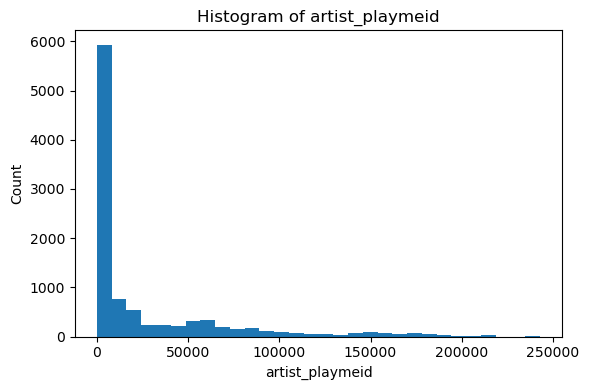

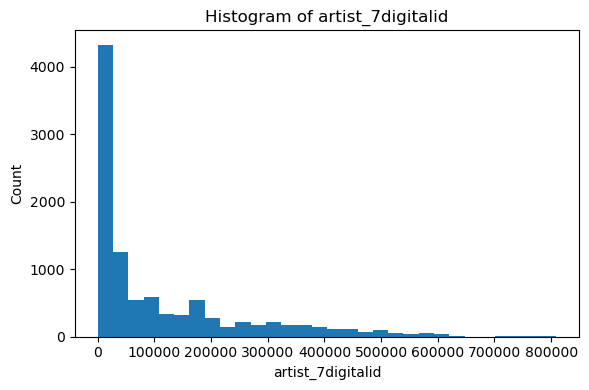

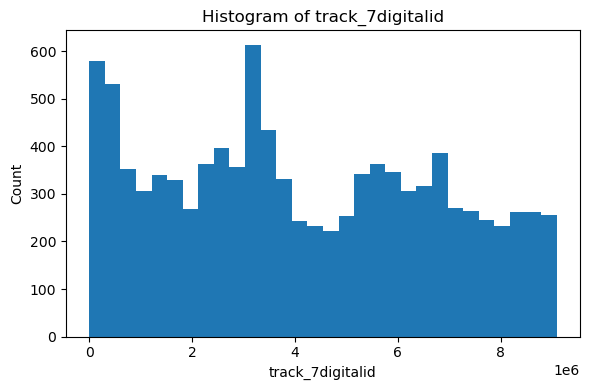

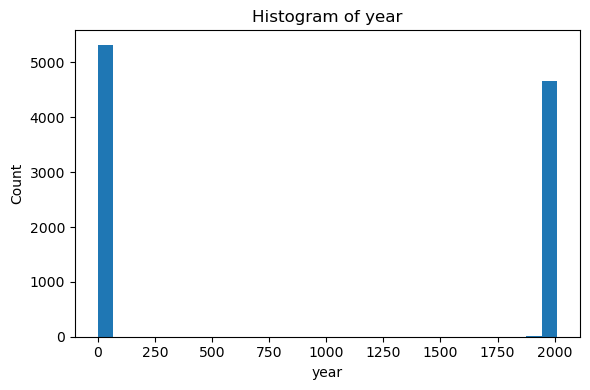

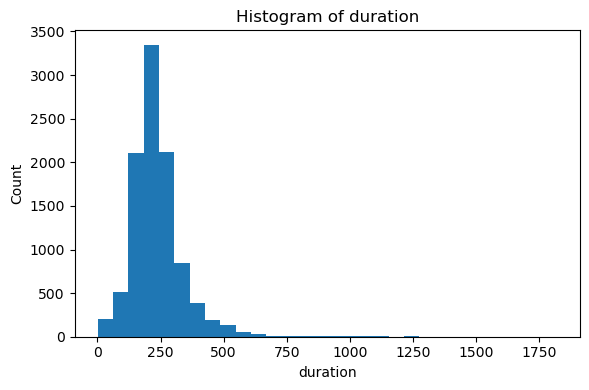

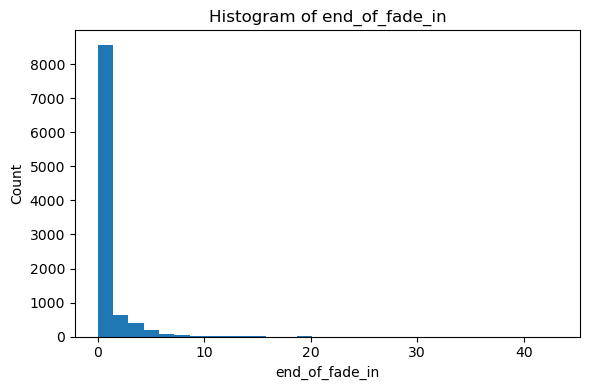

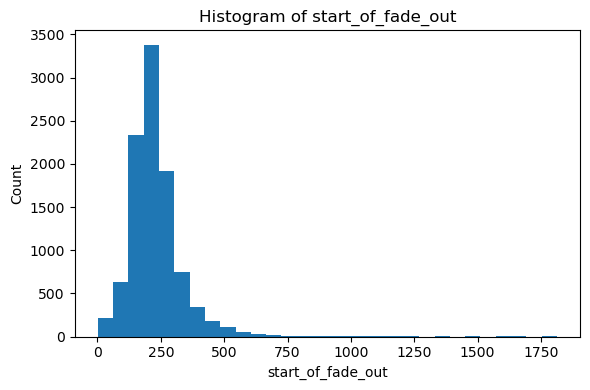

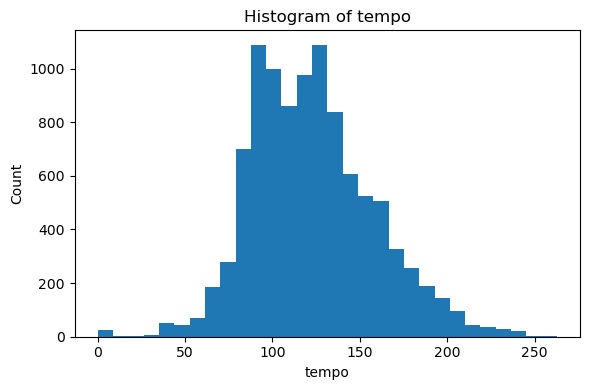

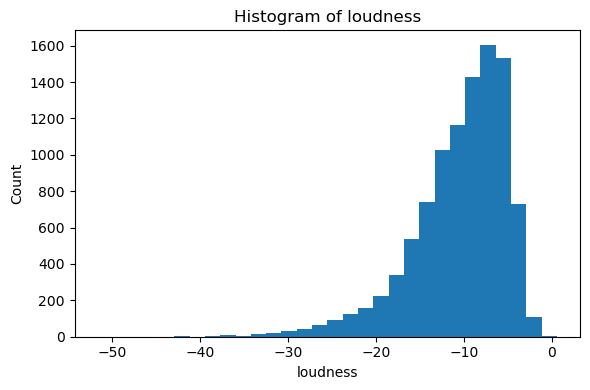

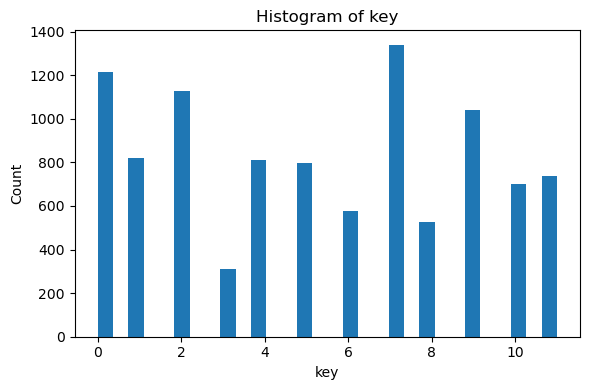

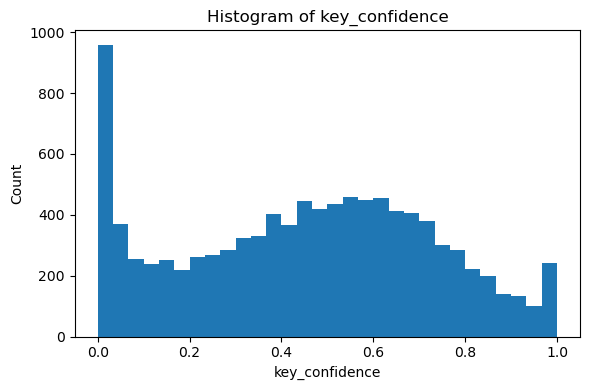

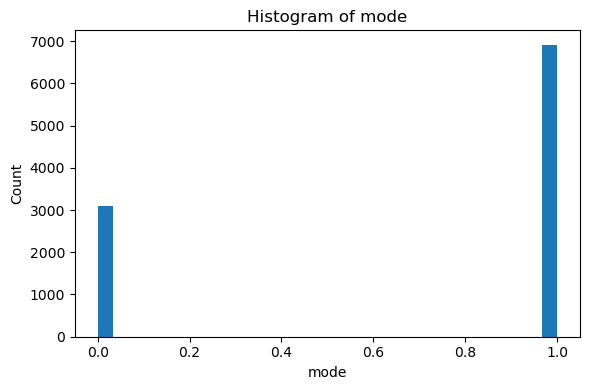

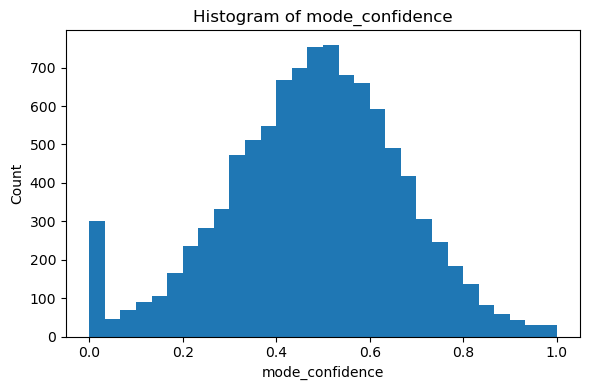

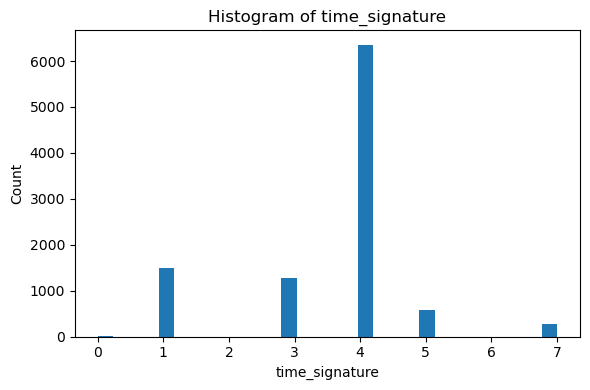

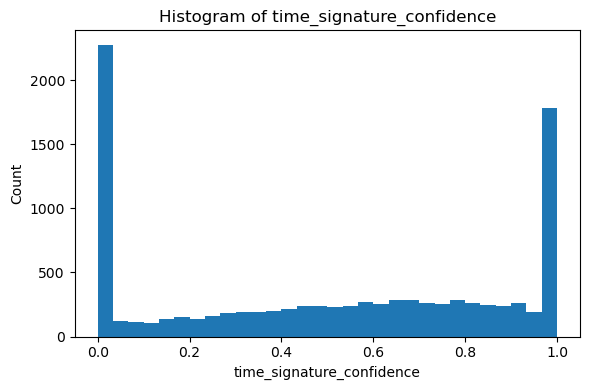

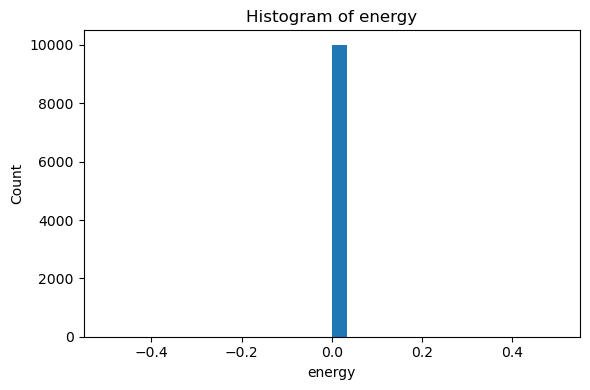

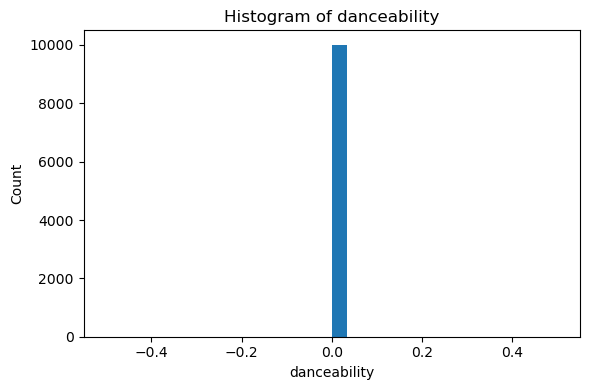

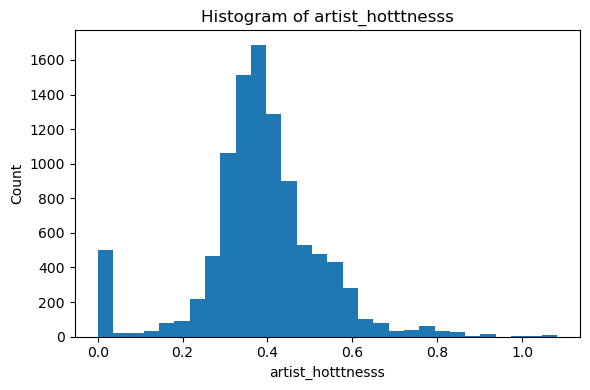

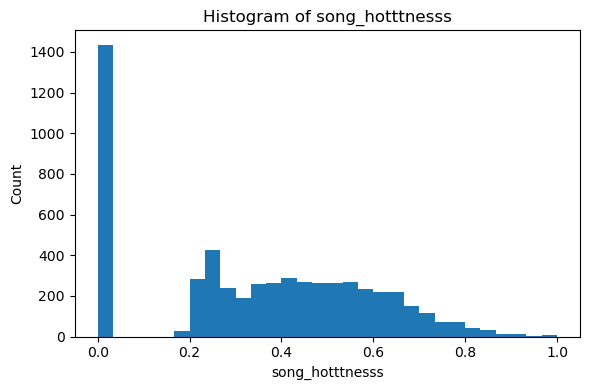

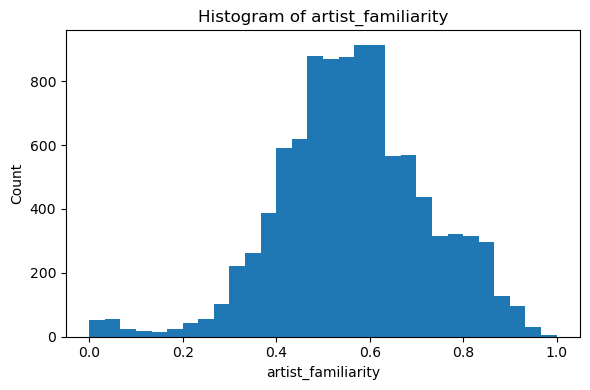

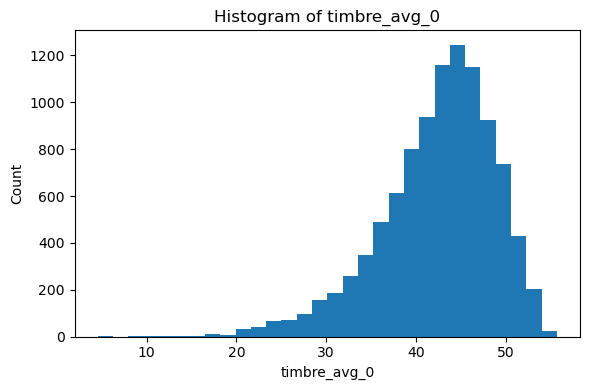

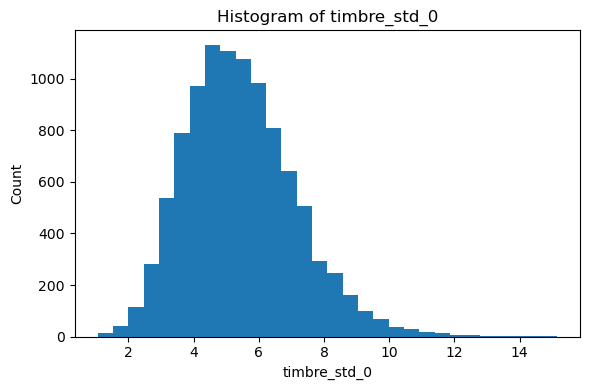

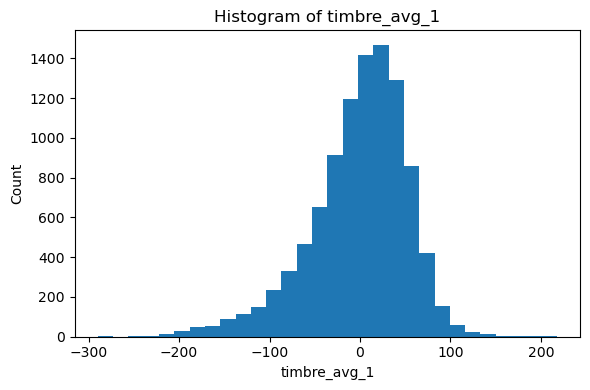

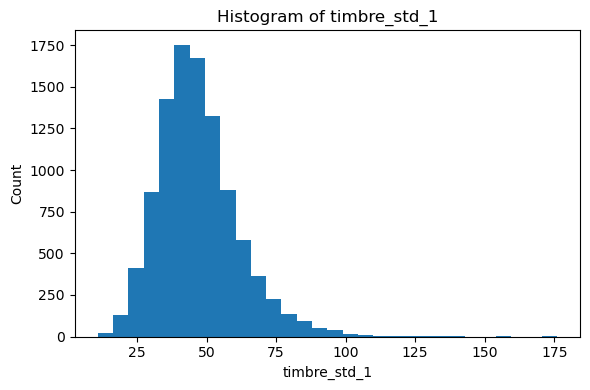

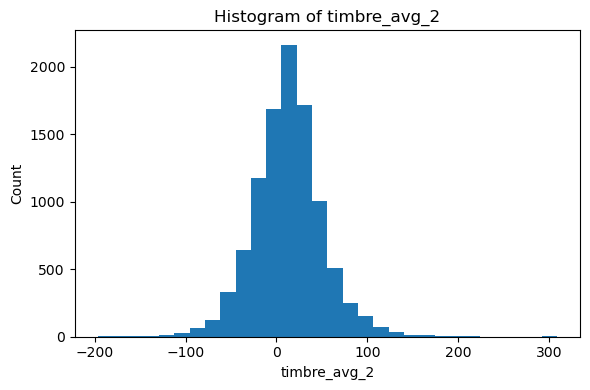

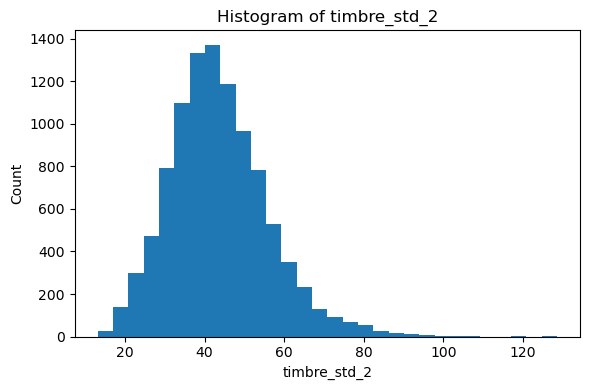

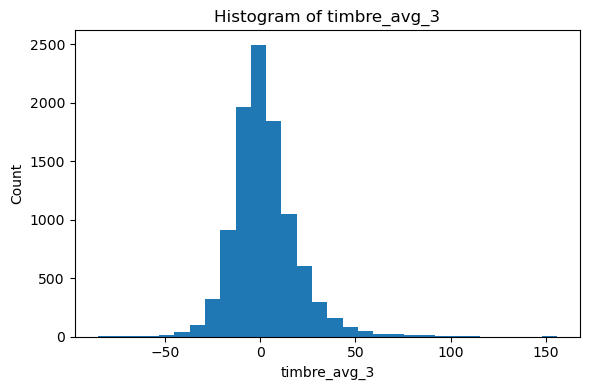

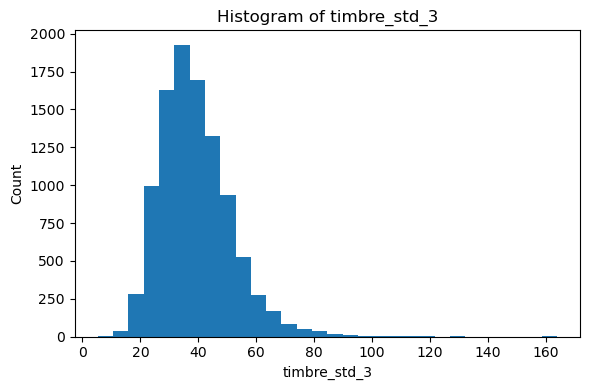

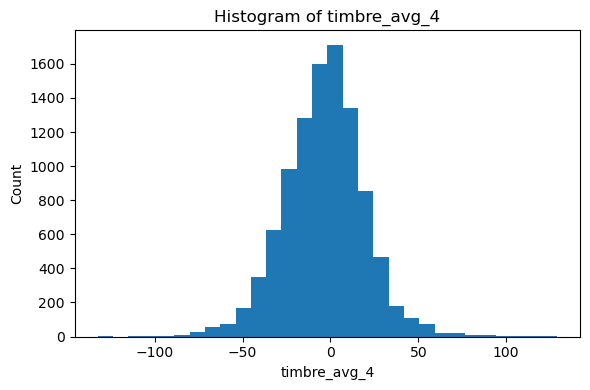

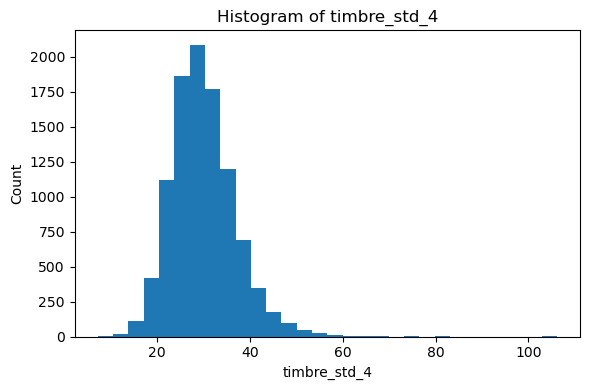

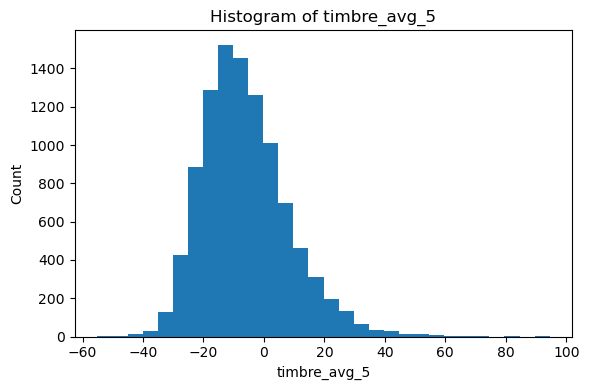

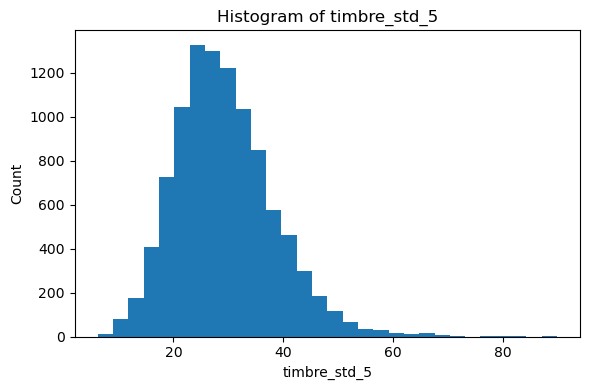

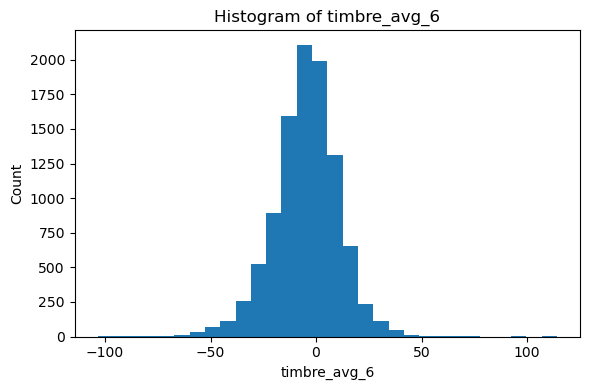

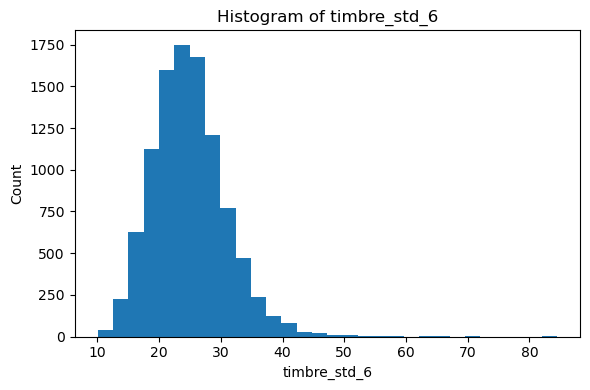

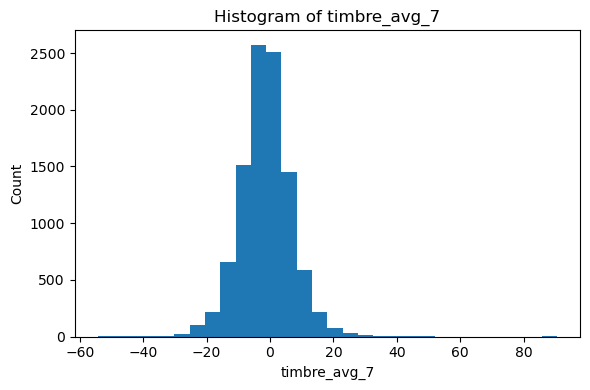

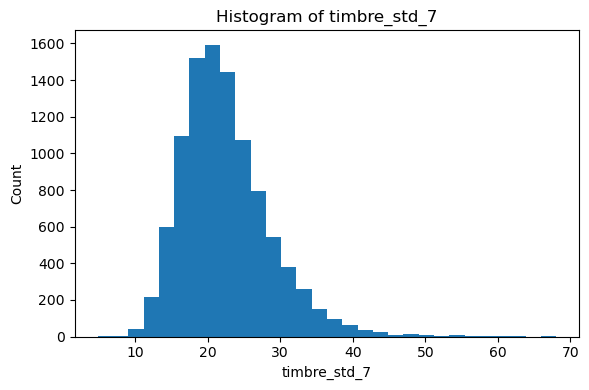

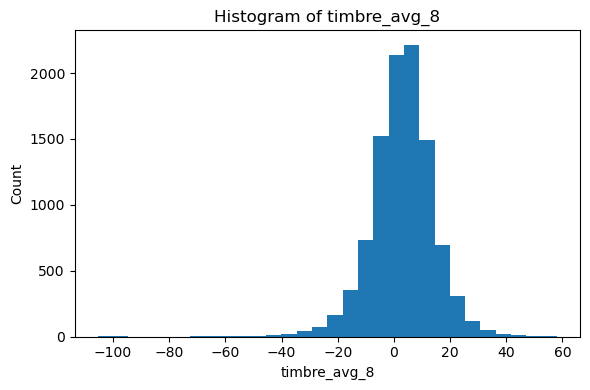

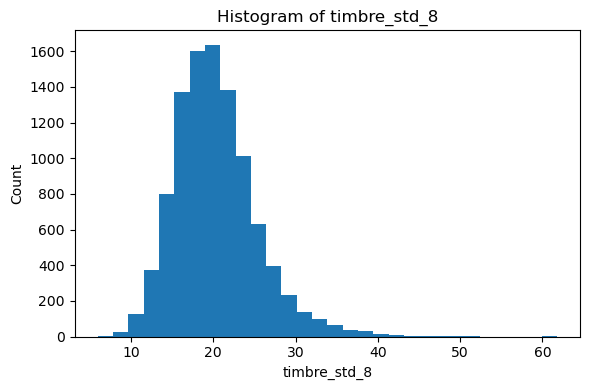

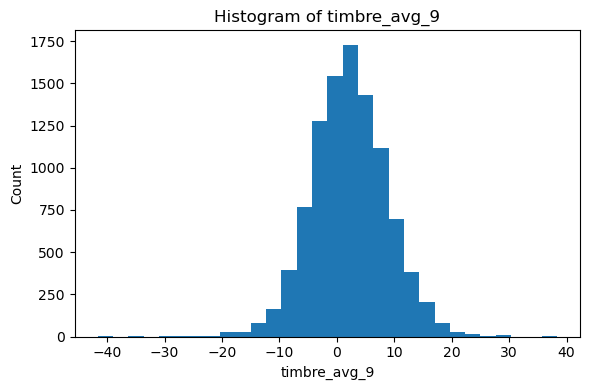

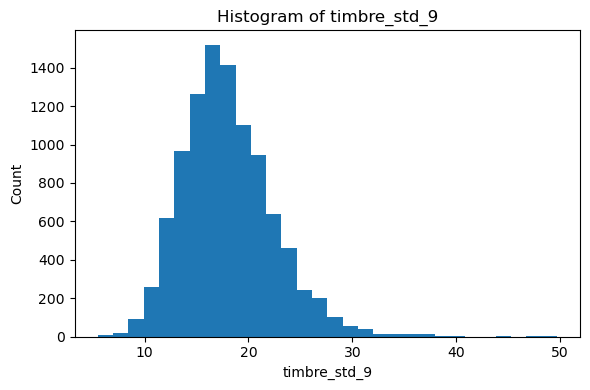

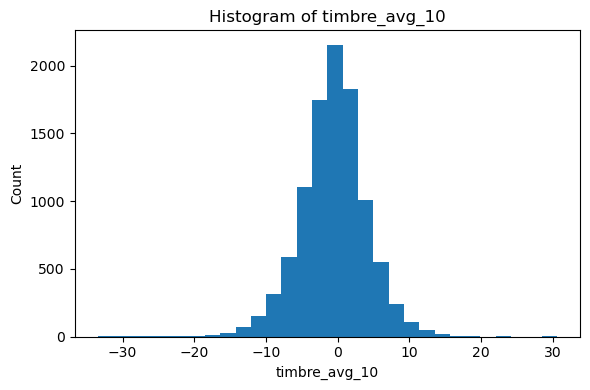

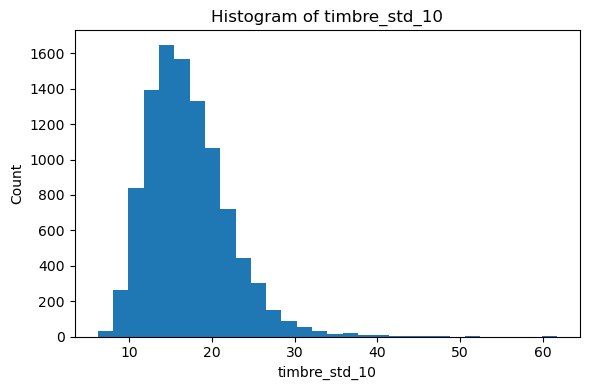

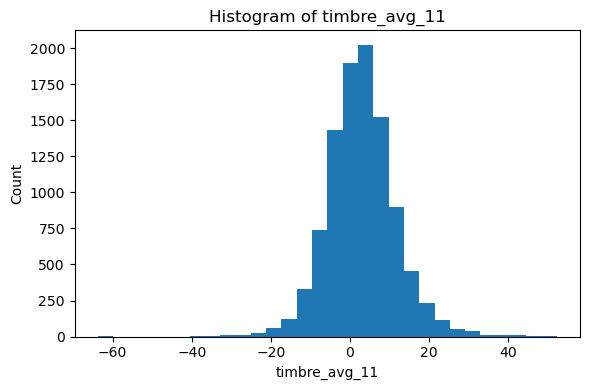

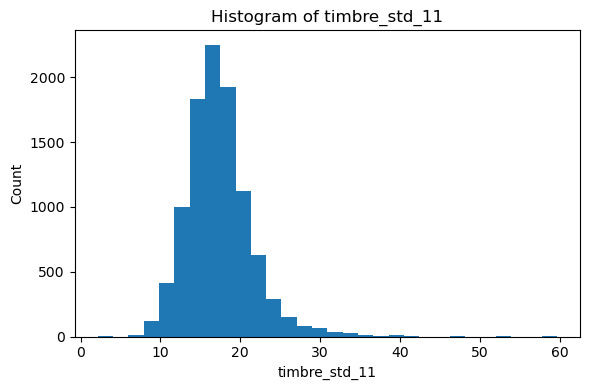

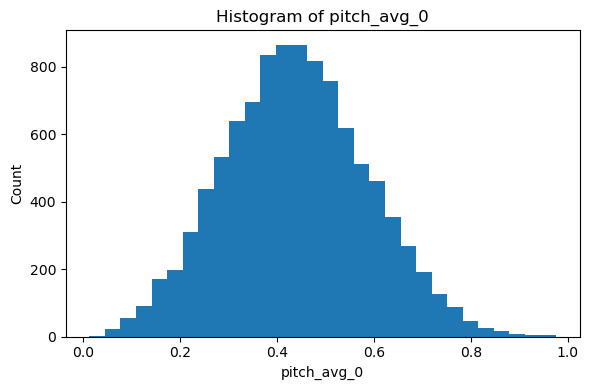

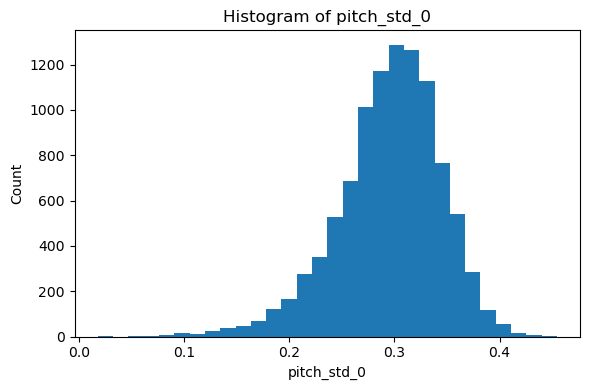

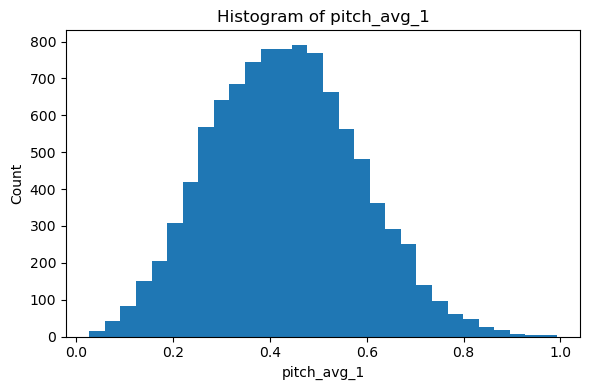

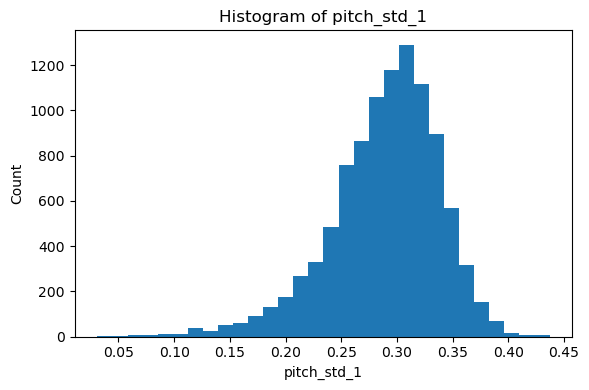

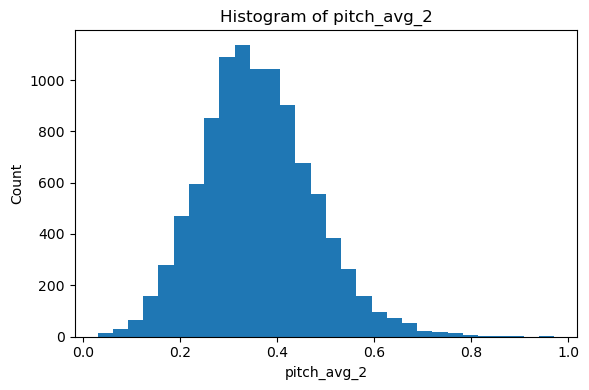

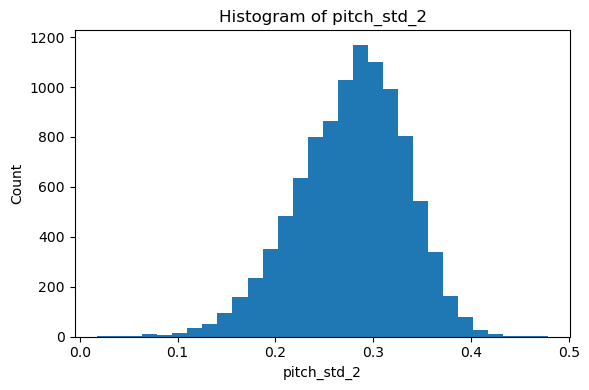

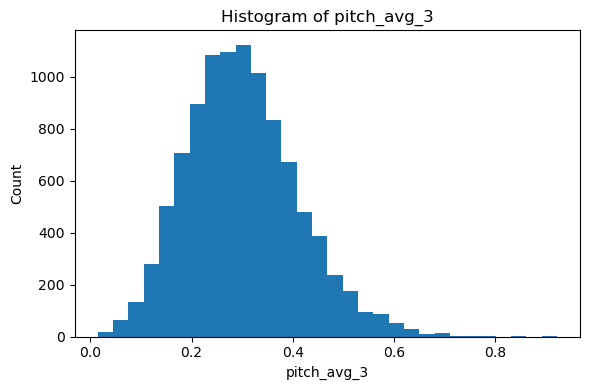

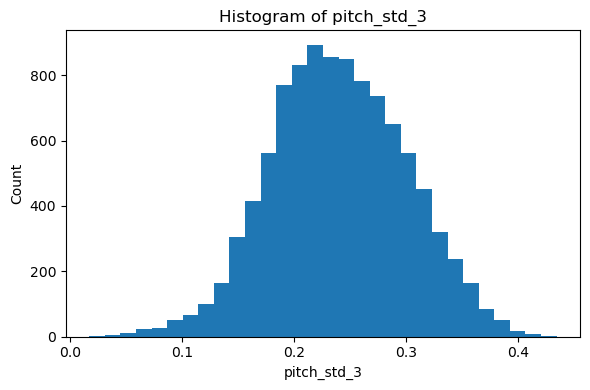

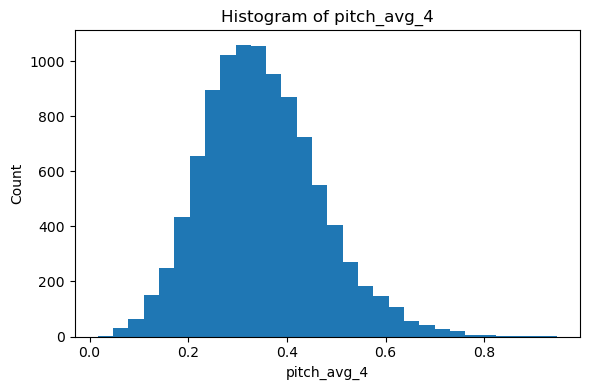

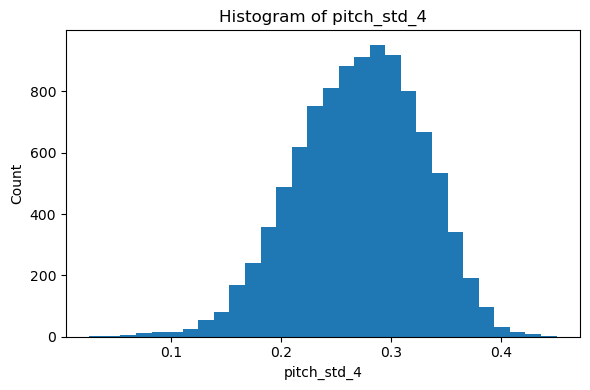

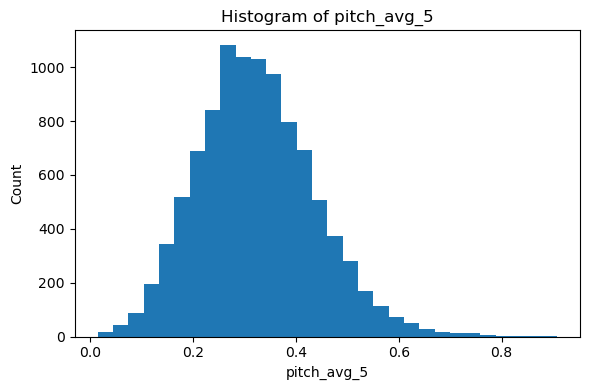

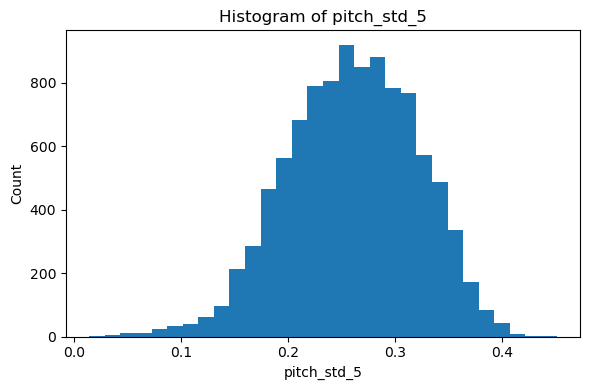

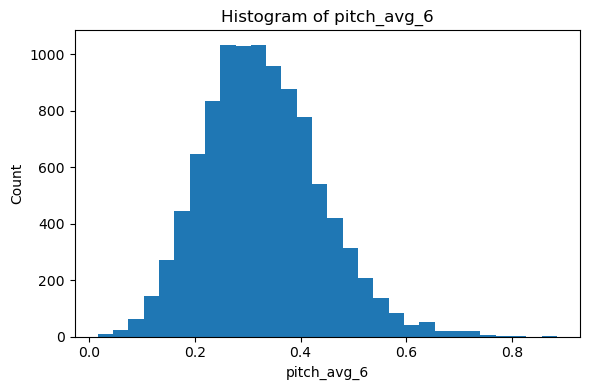

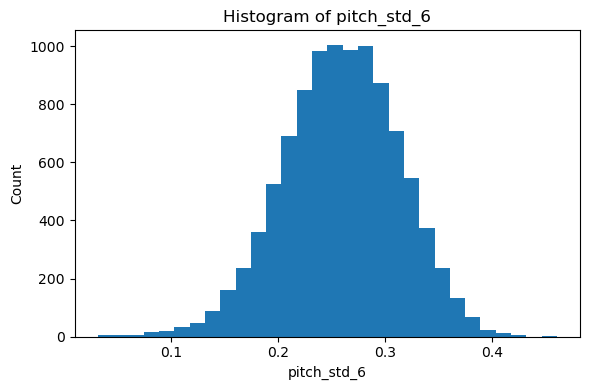

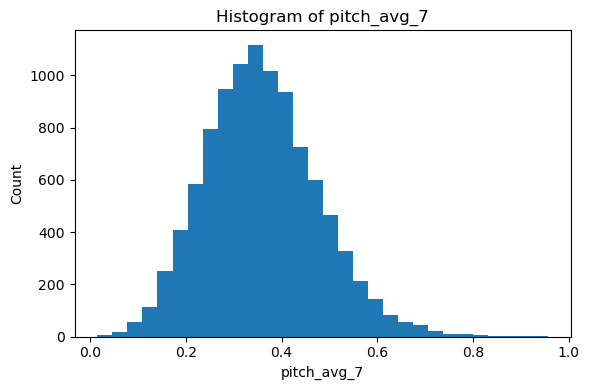

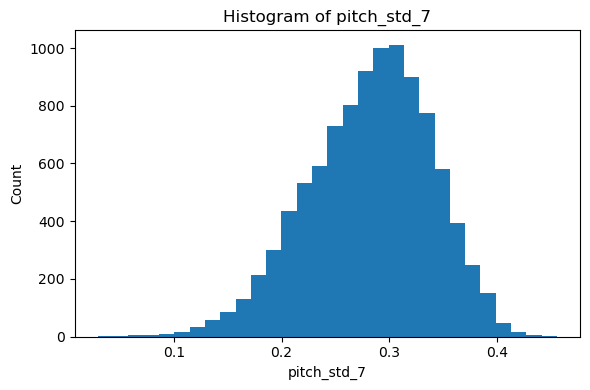

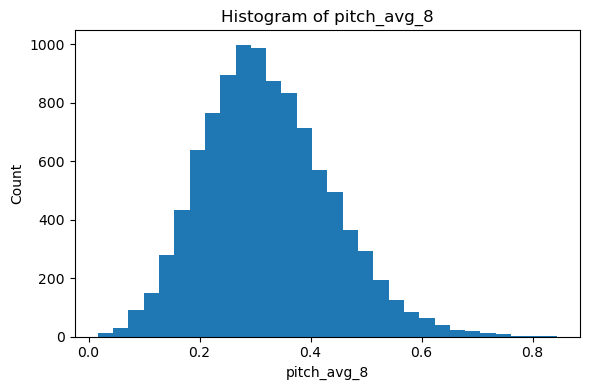

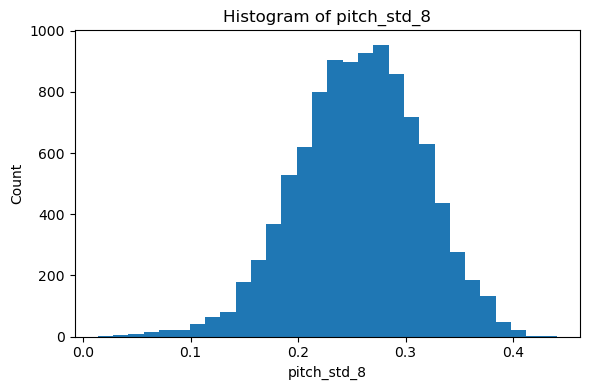

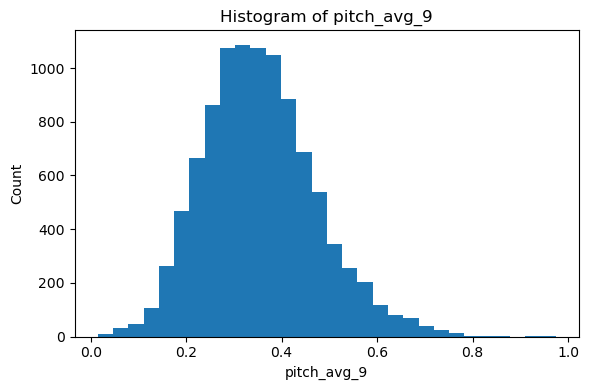

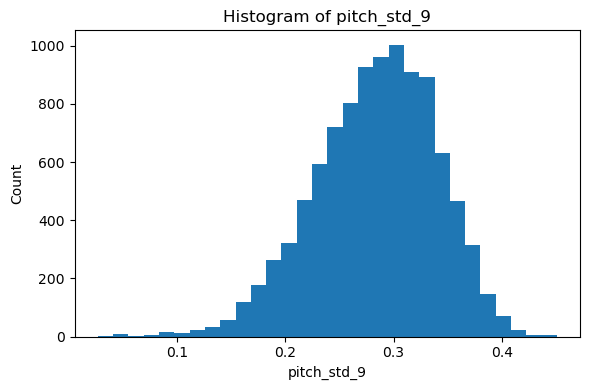

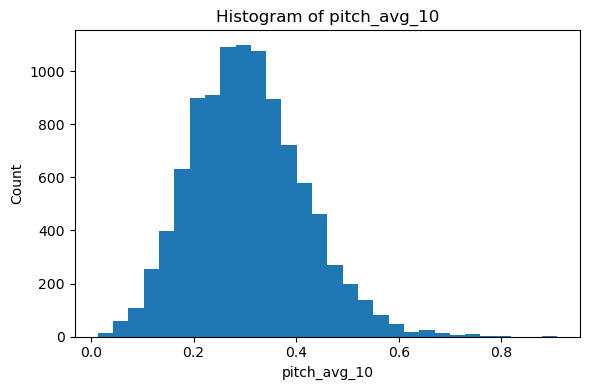

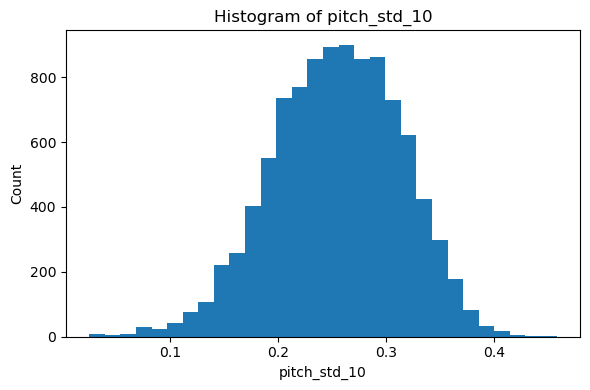

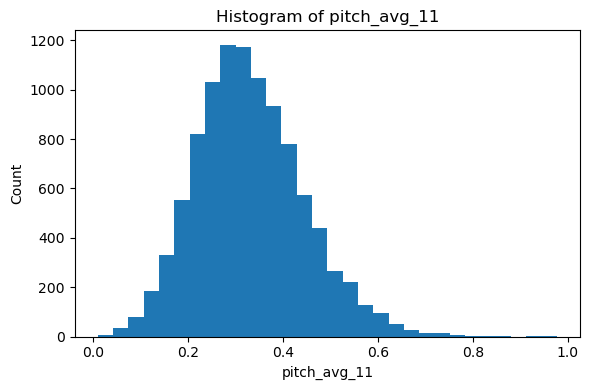

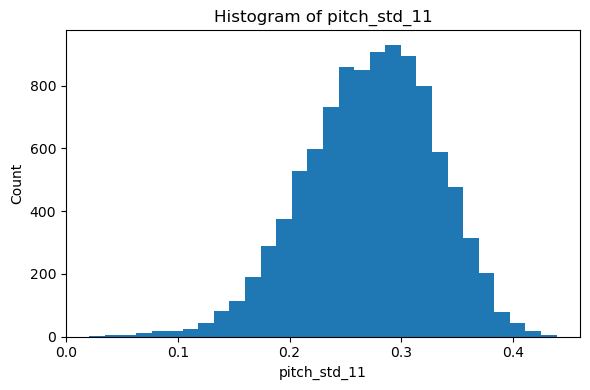

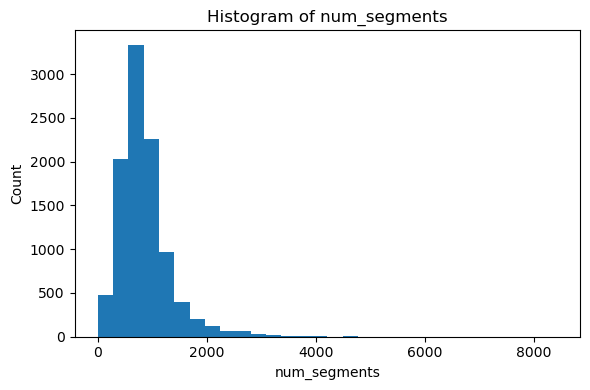

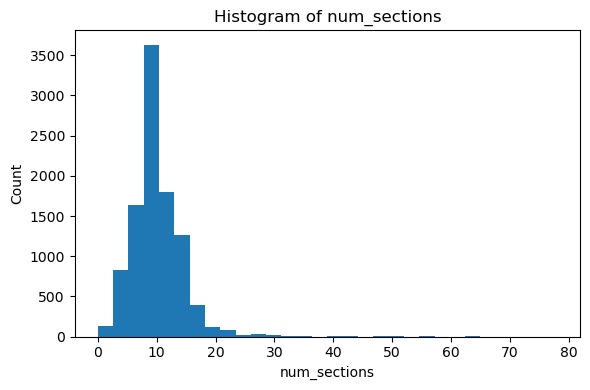

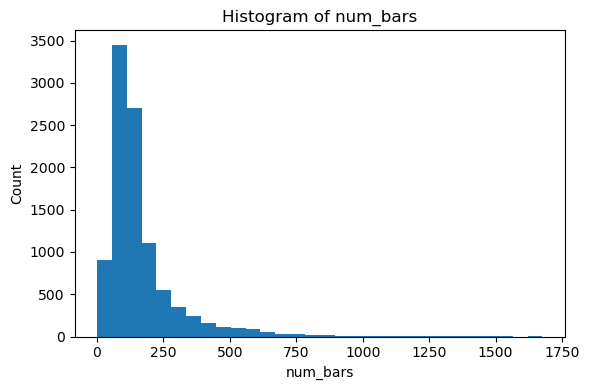

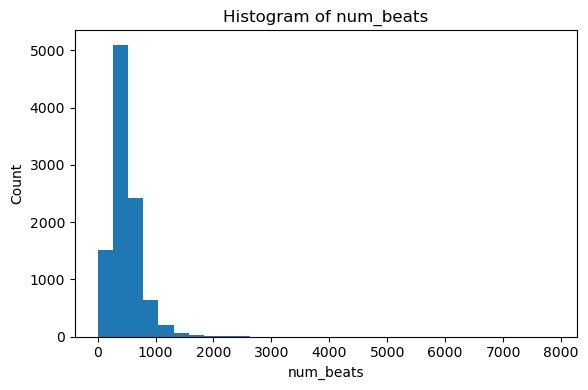

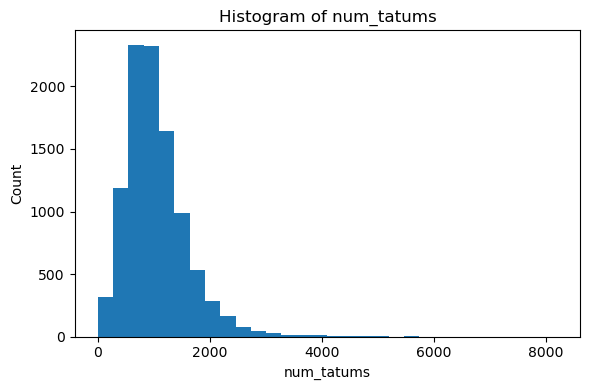

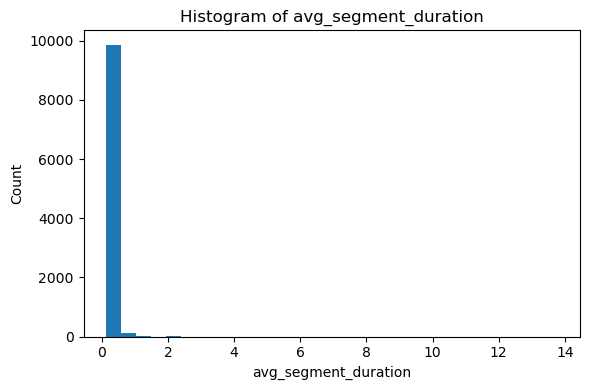

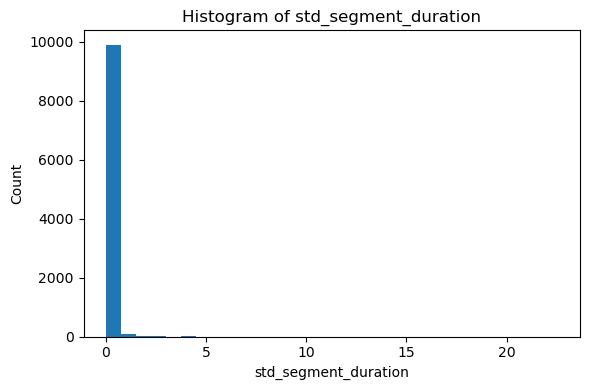

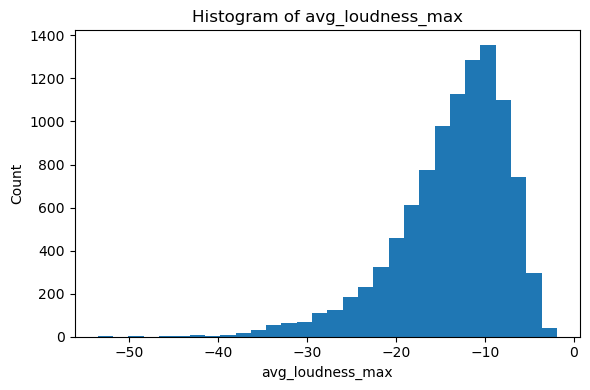

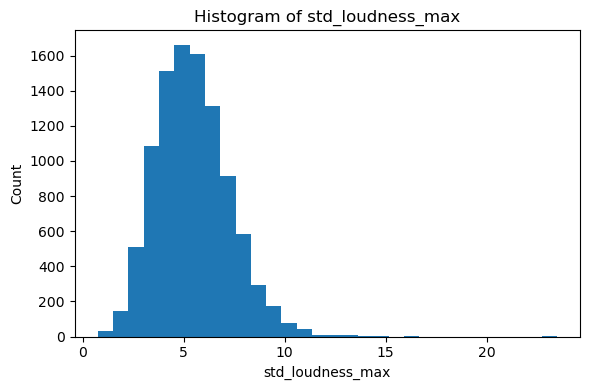

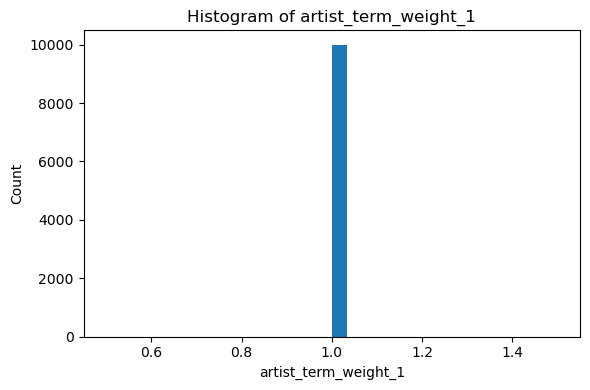

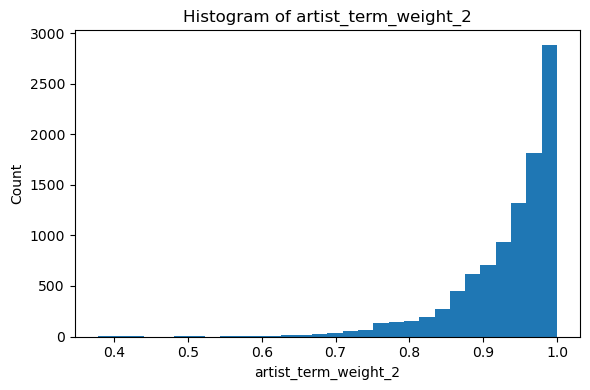

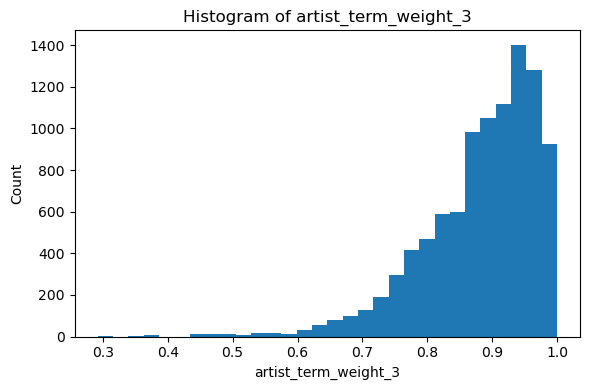

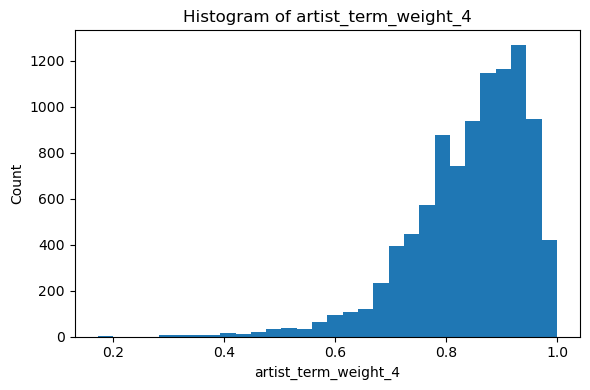

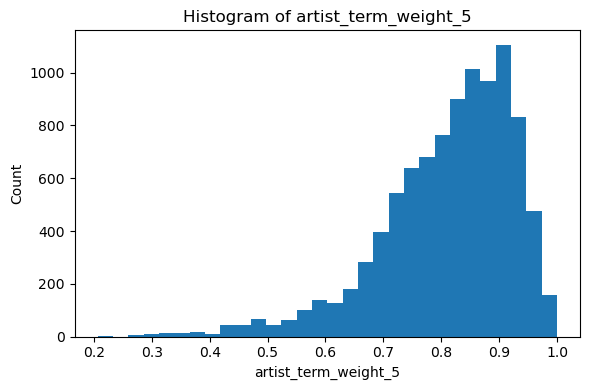

In [10]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(data[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Data Cleaning

### Check for misiing values and count zeroes in key features

In [11]:
# Check for missing values in key variables
print("Missing Values Analysis for Key Variables:")
print("-" * 50)

key_vars = ['tempo', 'danceability', 'energy', 'loudness', 'year', 'song_hotttnesss', 
            'artist_name', 'title', 'key', 'mode', 'time_signature', 'duration']
available_vars = [var for var in key_vars if var in data.columns]

missing_summary = []
for var in available_vars:
    missing_count = data[var].isna().sum()
    missing_pct = (missing_count / len(data)) * 100
    missing_summary.append({
        'Variable': var,
        'Missing Count': missing_count,
        'Missing %': f"{missing_pct:.2f}%"
    })
missing_df = pd.DataFrame(missing_summary)
print(missing_df.to_string(index=False))

# print(data.describe())
# 
print("\nCounting Zeros of key variables:")
print("-" * 50)
for var in available_vars:
    zeros_in_col1 = (data[var] == 0).sum()
    print(f"Number of zeros in {var}: {zeros_in_col1}")



Missing Values Analysis for Key Variables:
--------------------------------------------------
       Variable  Missing Count Missing %
          tempo              0     0.00%
   danceability              0     0.00%
         energy              0     0.00%
       loudness              0     0.00%
           year              0     0.00%
song_hotttnesss           4352    43.52%
    artist_name              0     0.00%
          title              1     0.01%
            key              0     0.00%
           mode              0     0.00%
 time_signature              0     0.00%
       duration              0     0.00%

Counting Zeros of key variables:
--------------------------------------------------
Number of zeros in tempo: 25
Number of zeros in danceability: 10000
Number of zeros in energy: 10000
Number of zeros in loudness: 0
Number of zeros in year: 5320
Number of zeros in song_hotttnesss: 1434
Number of zeros in artist_name: 0
Number of zeros in title: 0
Number of zeros in key:

### Drop features with constant values

In [12]:
# Drop constant features 
cols_to_drop = ["energy", "danceability"]
clean_data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
# Confirm clean data
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 94 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   song_id                    10000 non-null  object 
 1   title                      9999 non-null   object 
 2   artist_name                10000 non-null  object 
 3   artist_id                  10000 non-null  object 
 4   release                    10000 non-null  object 
 5   artist_mbid                9281 non-null   object 
 6   artist_playmeid            10000 non-null  int64  
 7   artist_7digitalid          10000 non-null  int64  
 8   track_7digitalid           10000 non-null  int64  
 9   year                       10000 non-null  int64  
 10  duration                   10000 non-null  float64
 11  end_of_fade_in             10000 non-null  float64
 12  start_of_fade_out          10000 non-null  float64
 13  tempo                      10000 non-null  floa

## Outlier Detection

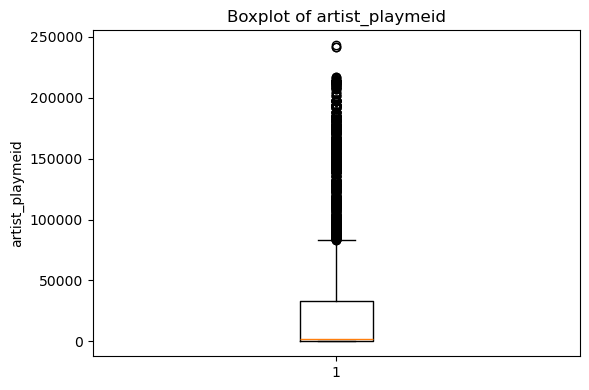

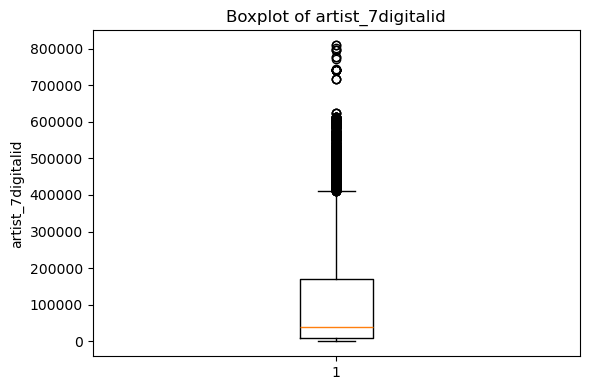

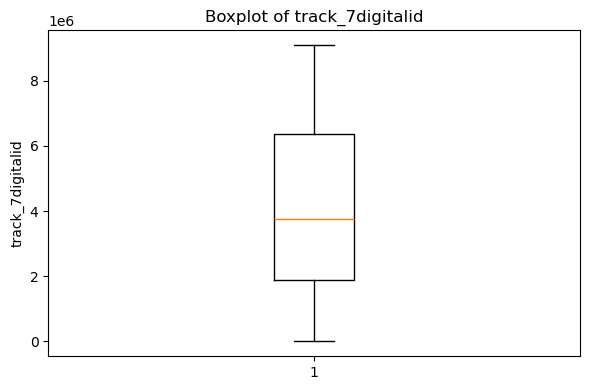

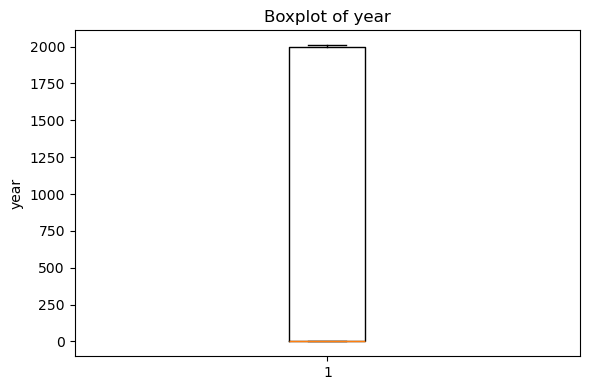

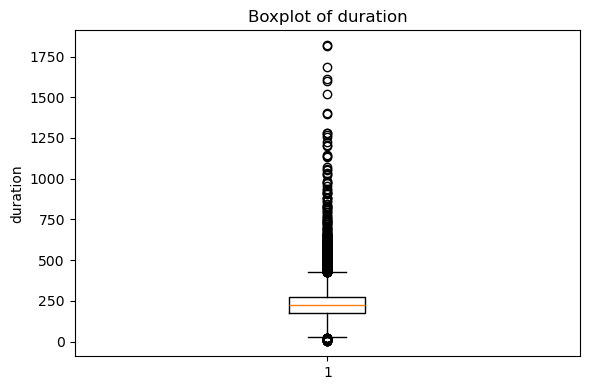

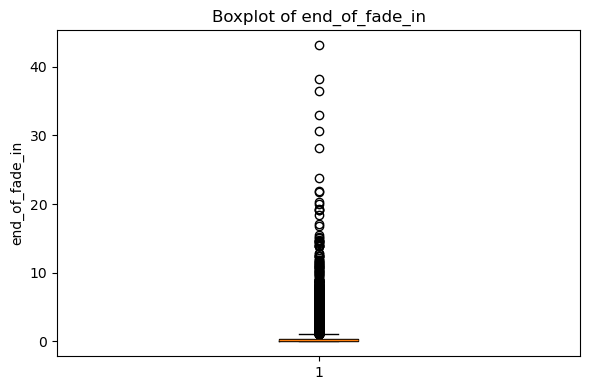

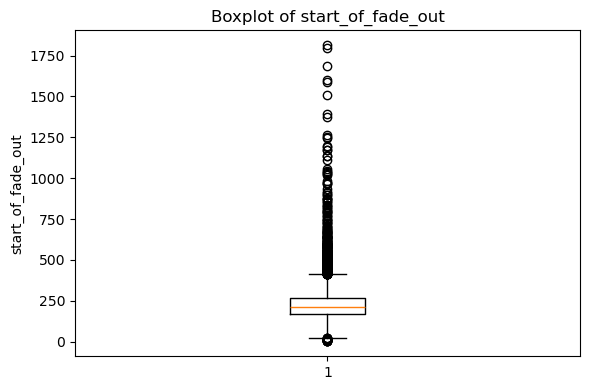

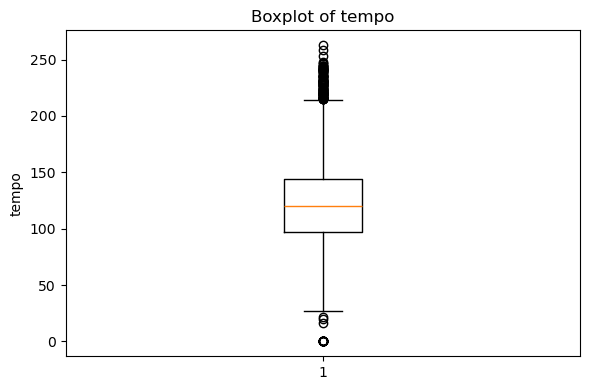

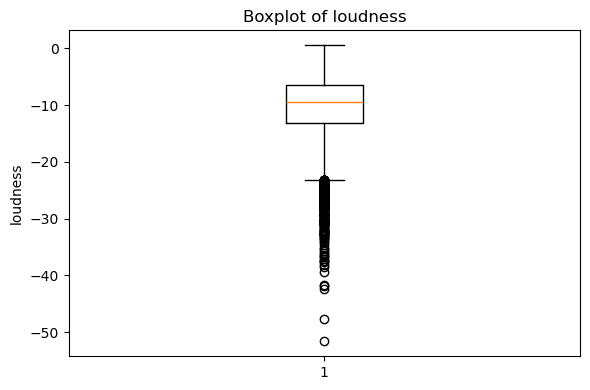

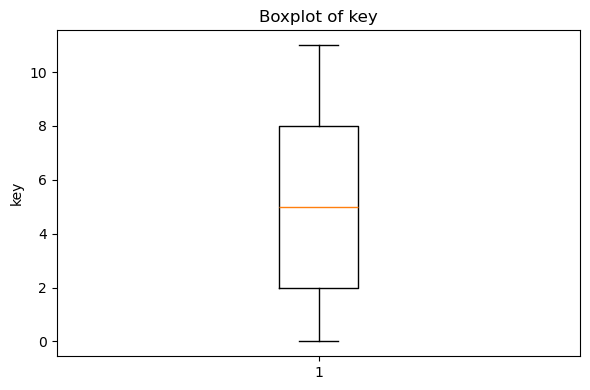

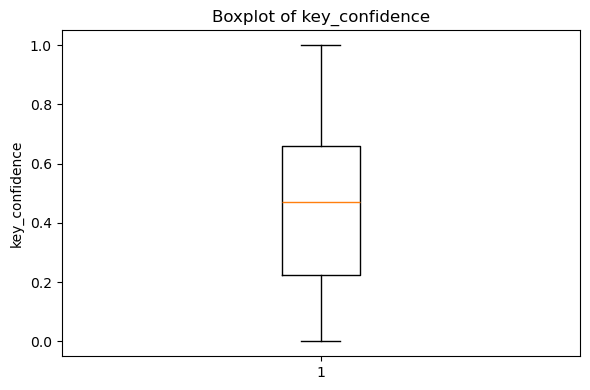

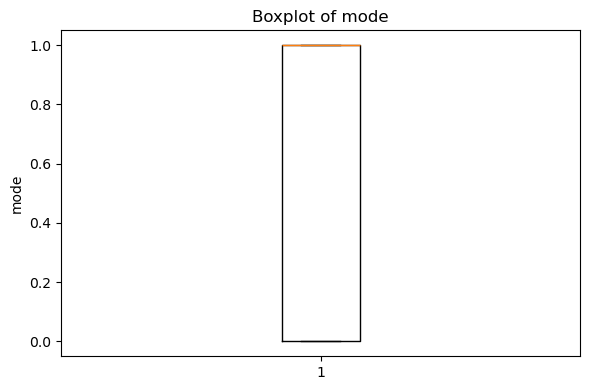

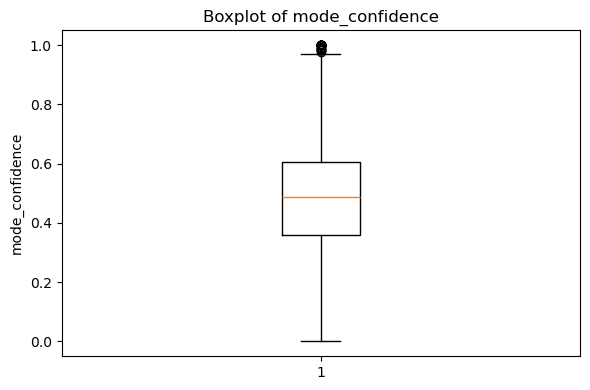

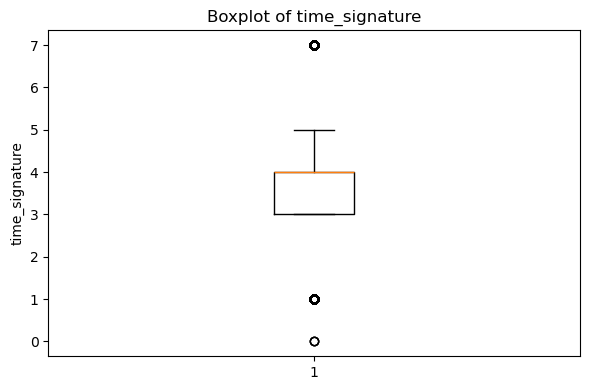

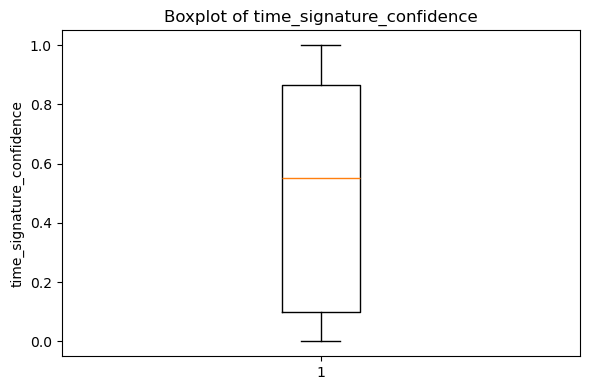

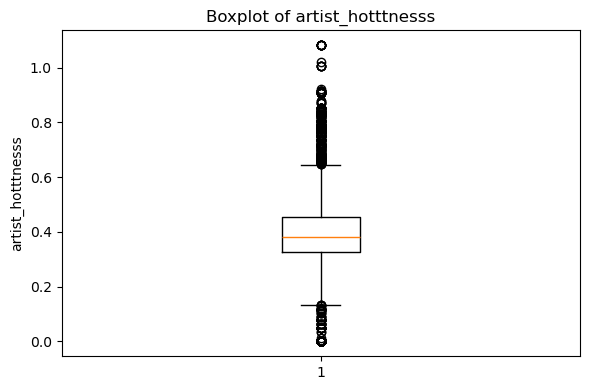

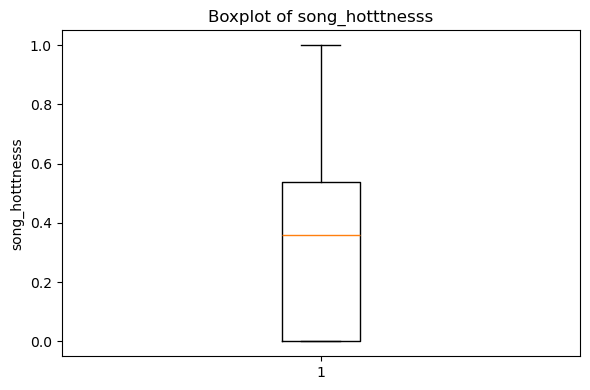

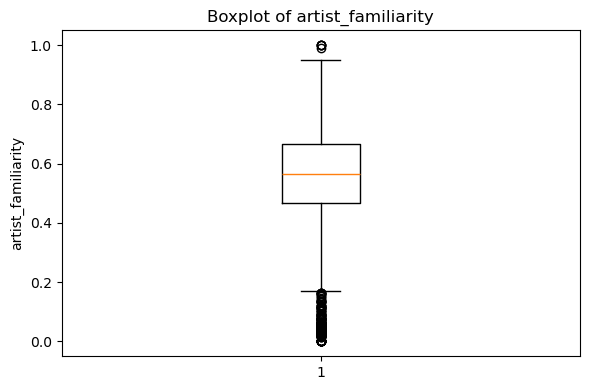

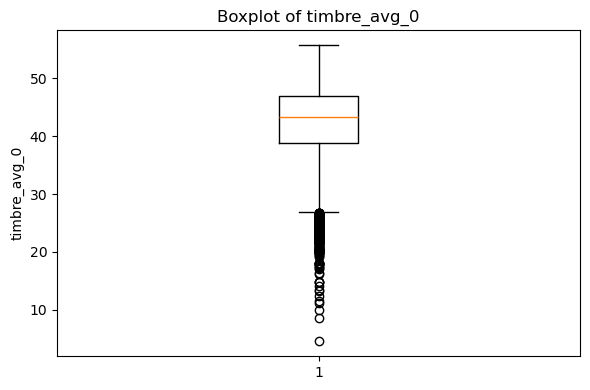

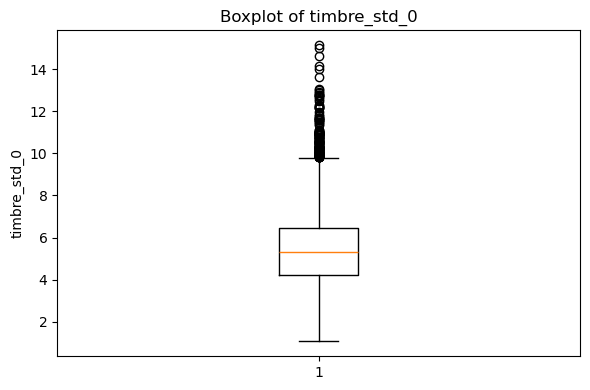

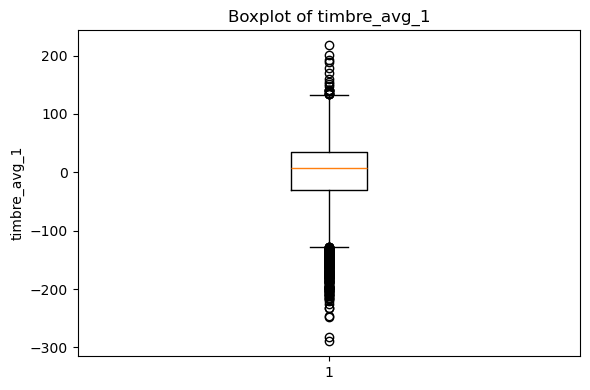

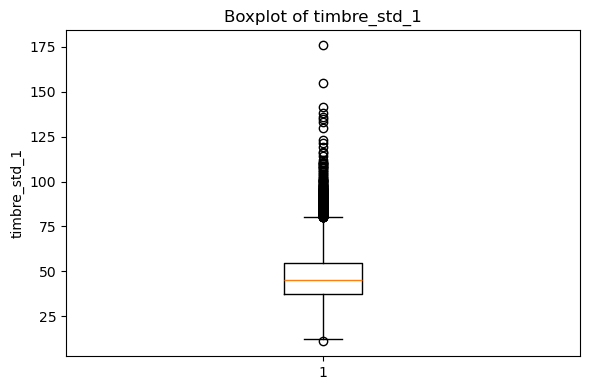

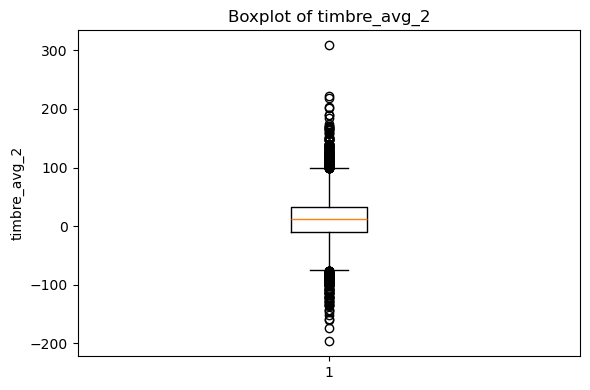

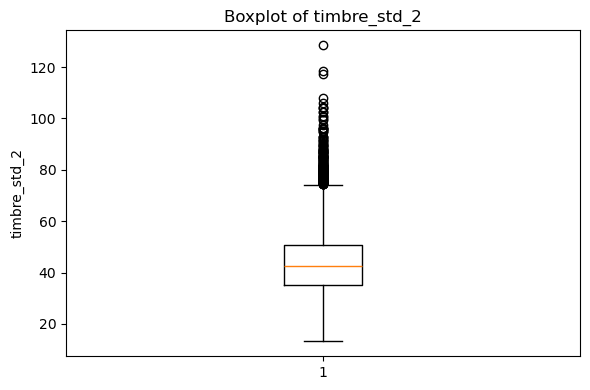

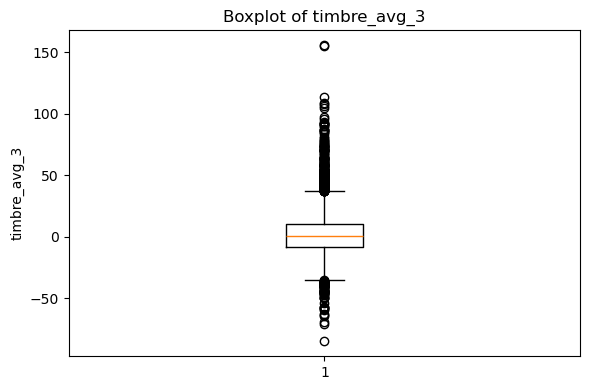

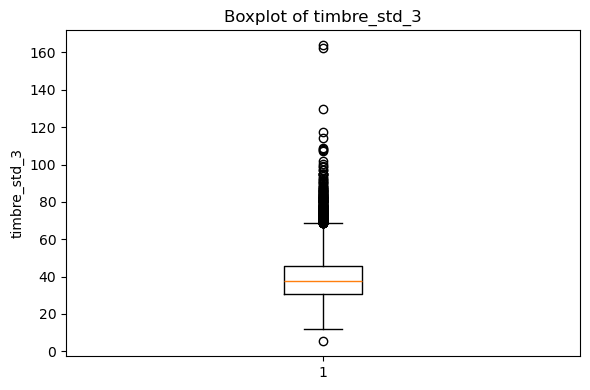

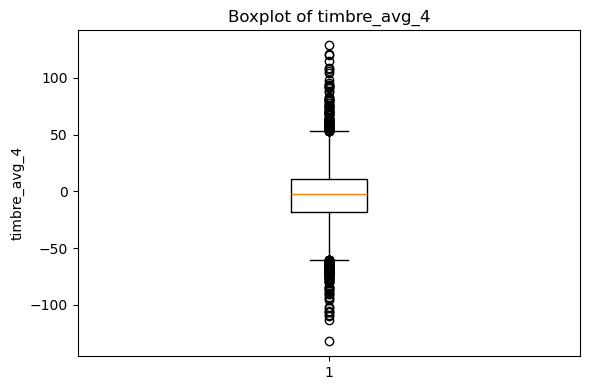

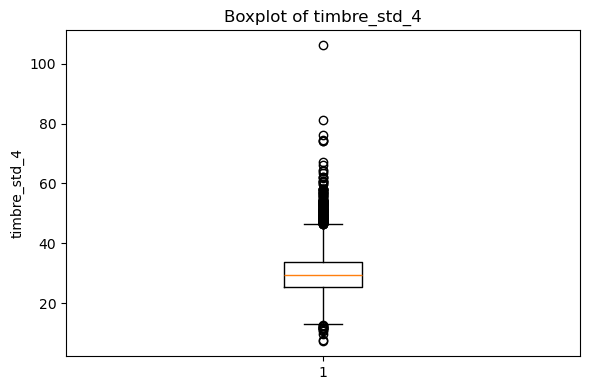

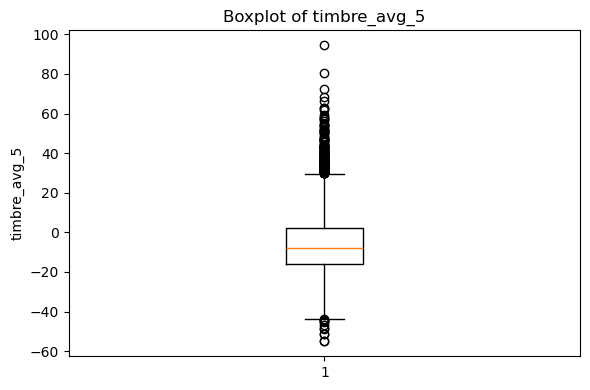

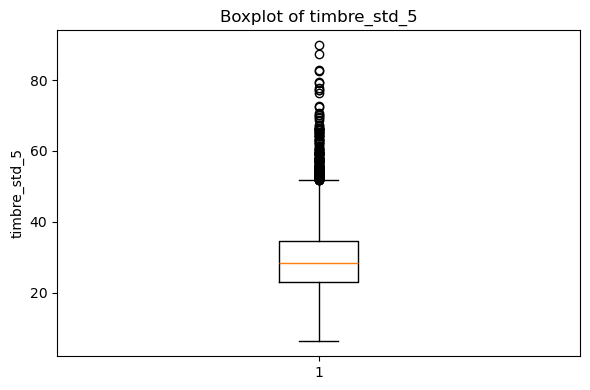

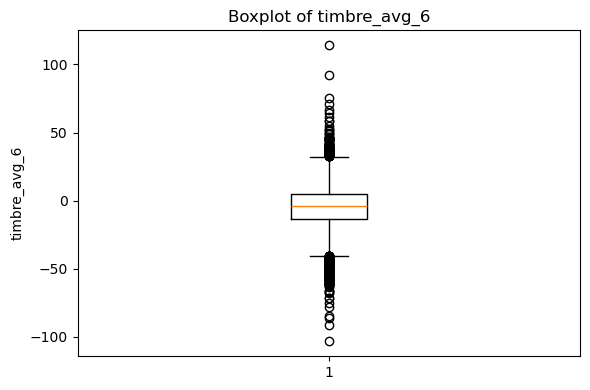

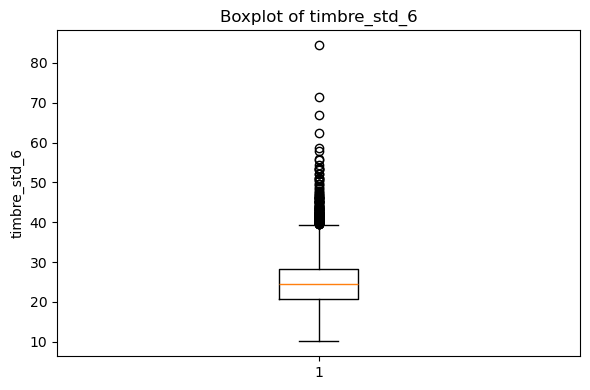

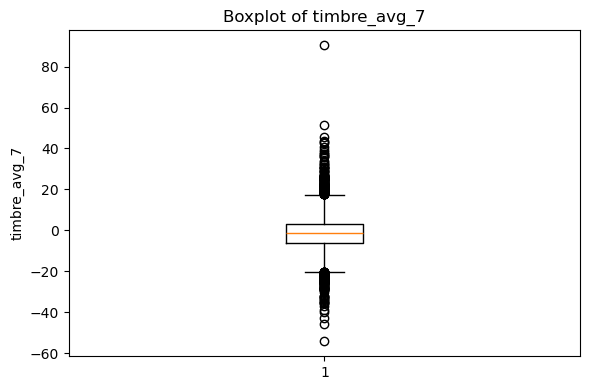

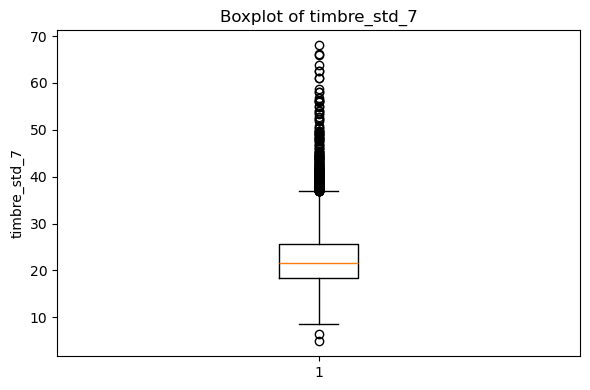

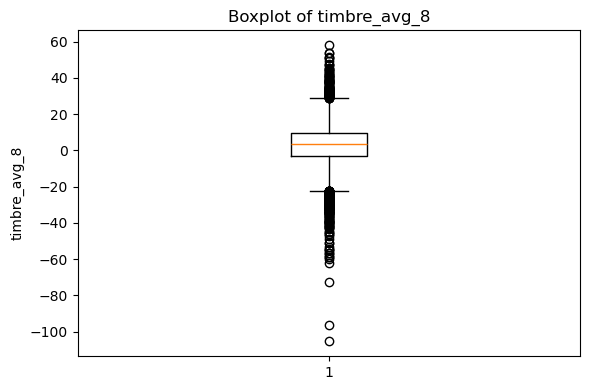

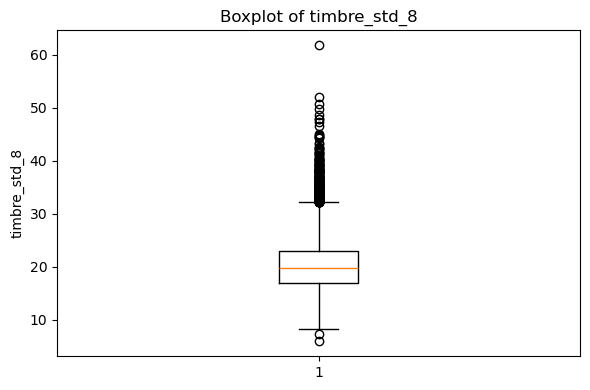

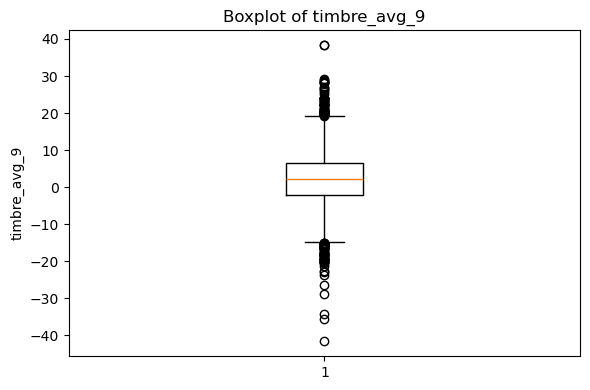

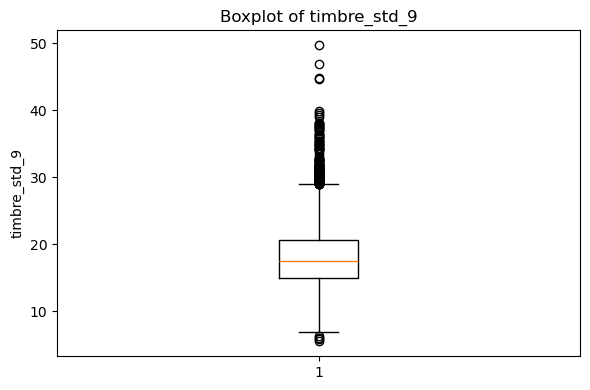

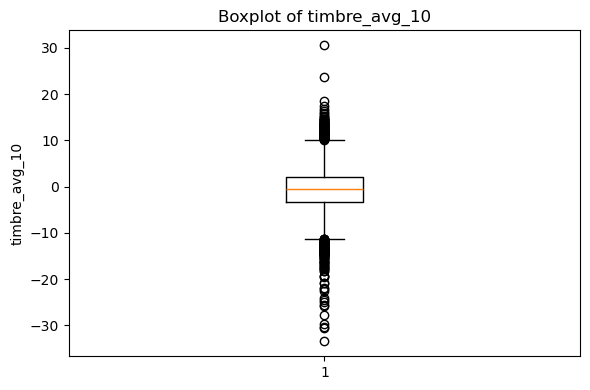

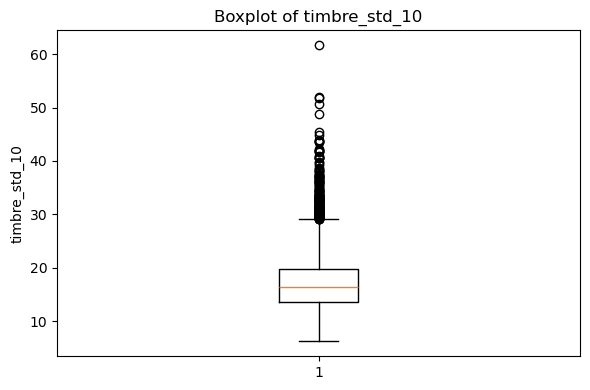

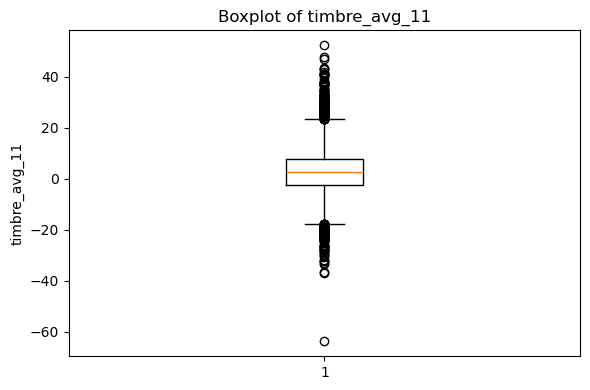

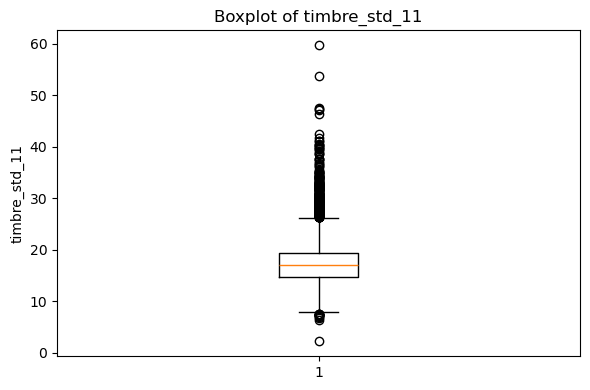

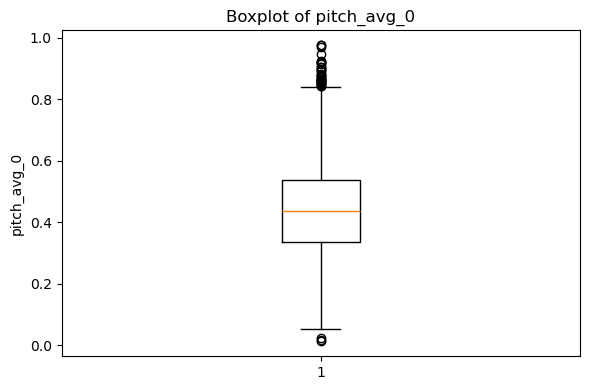

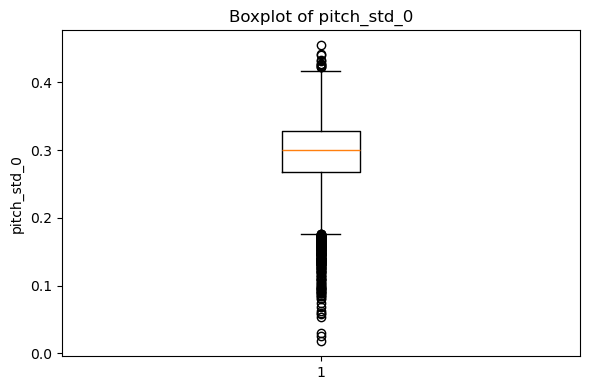

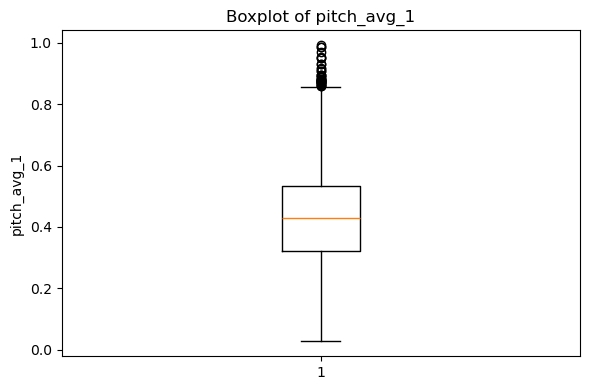

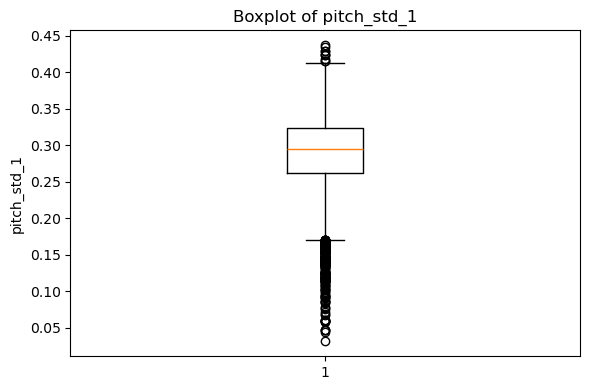

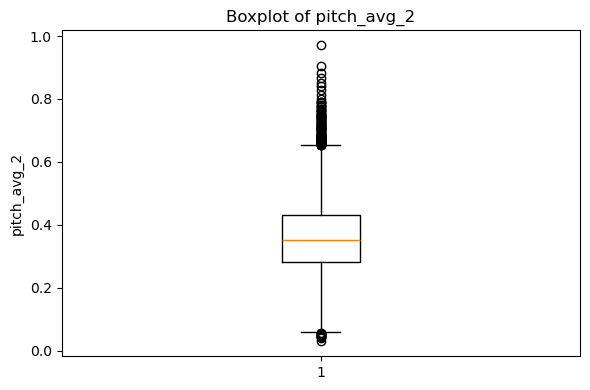

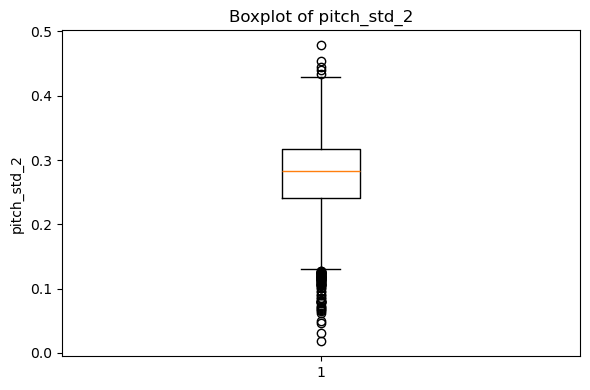

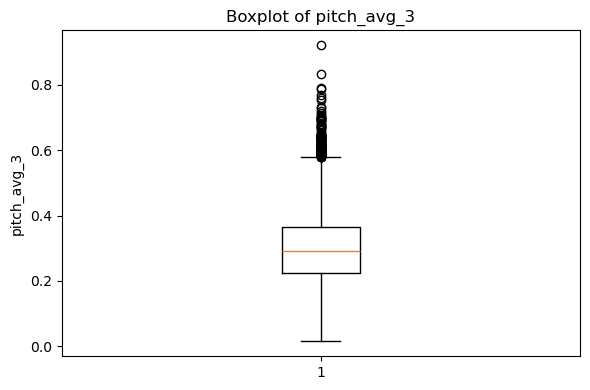

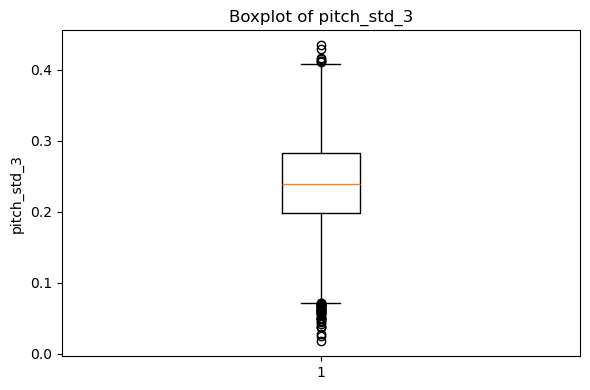

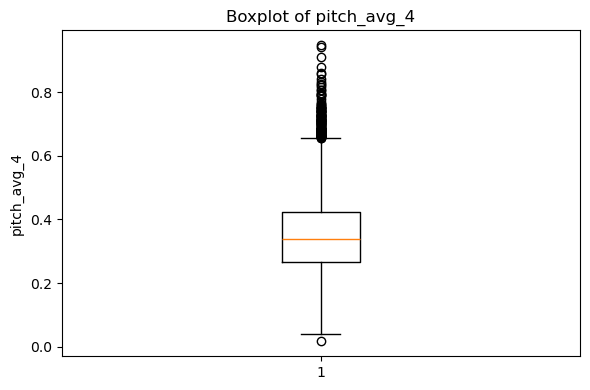

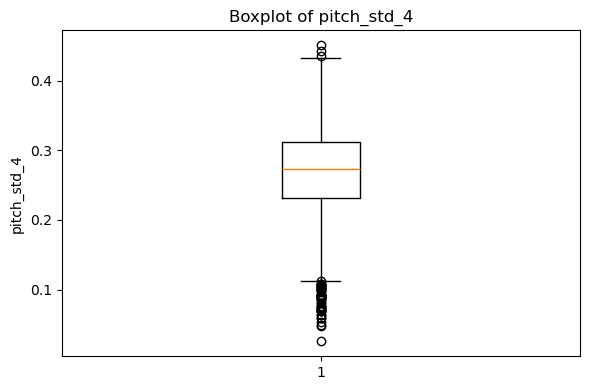

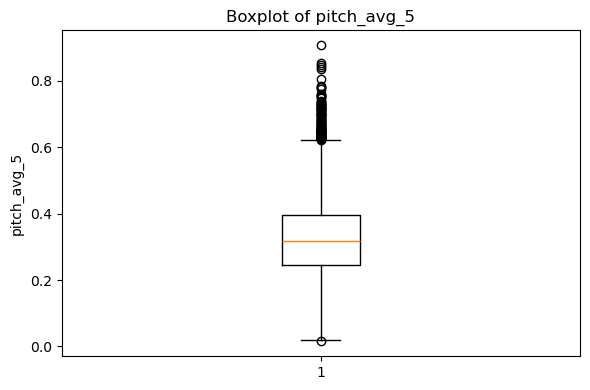

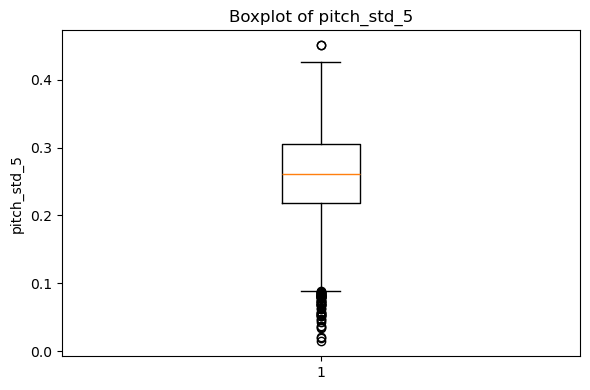

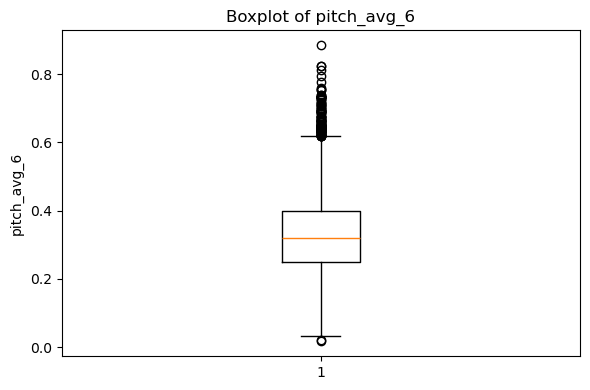

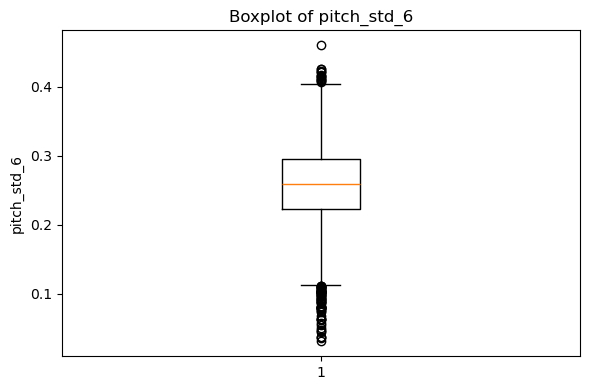

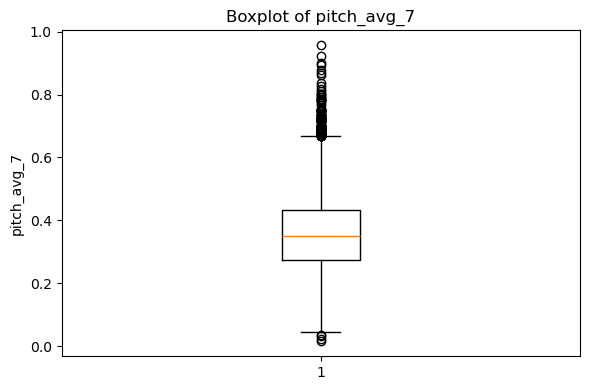

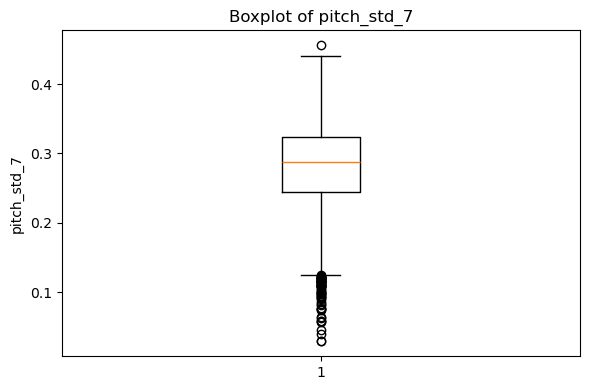

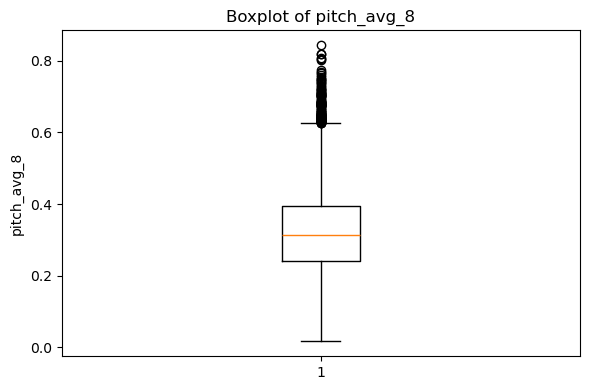

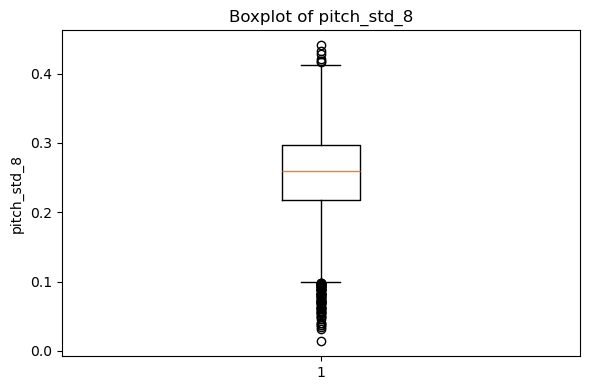

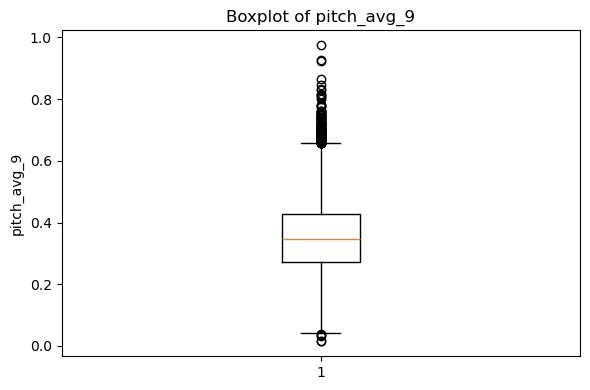

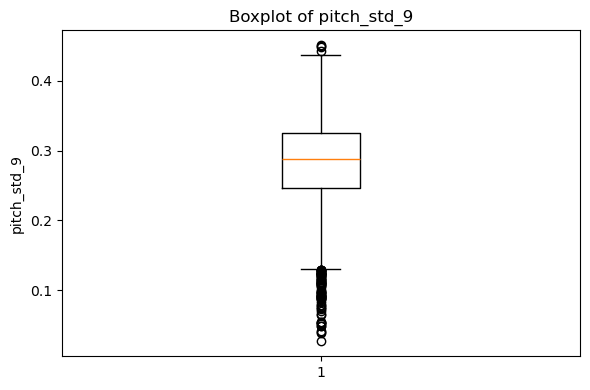

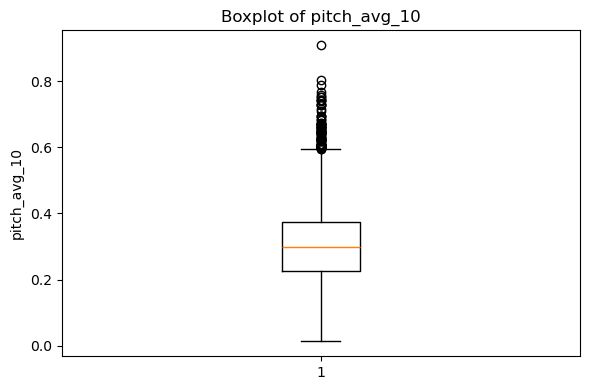

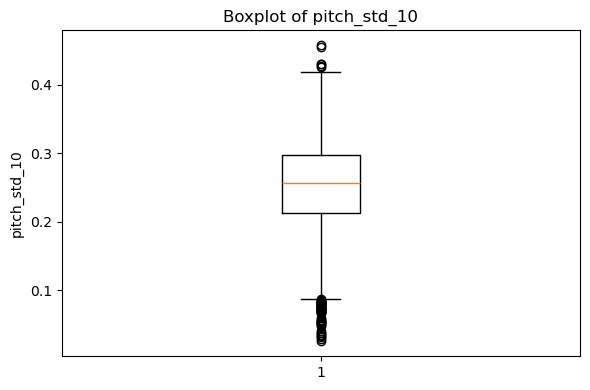

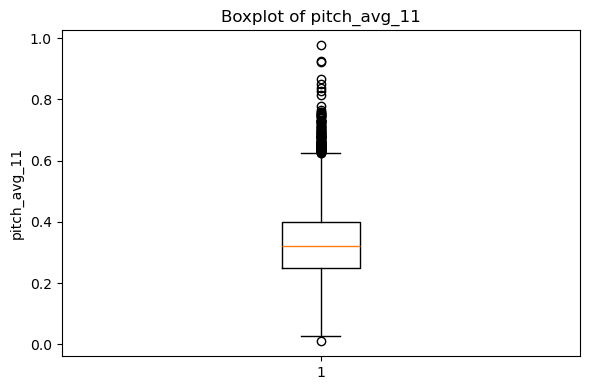

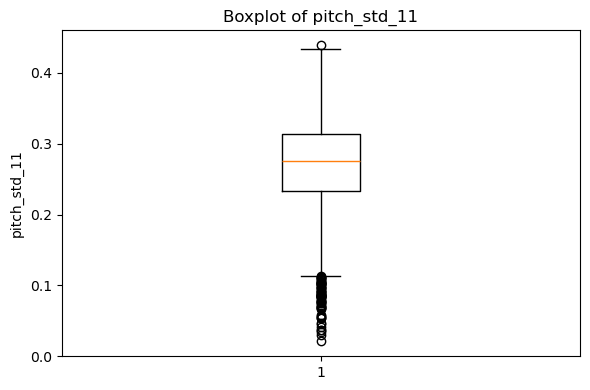

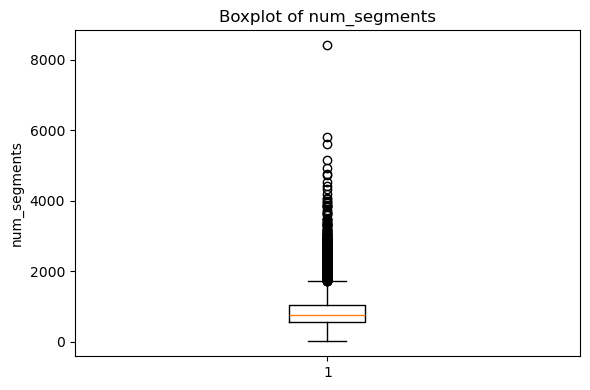

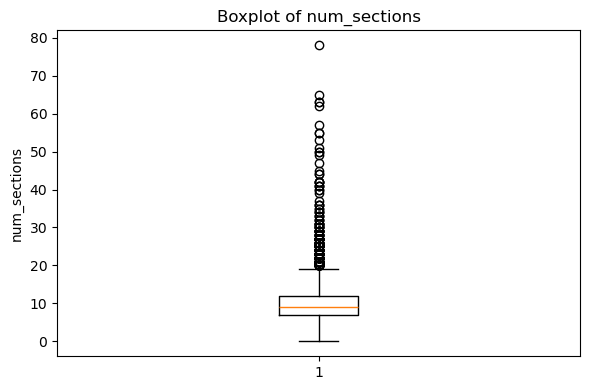

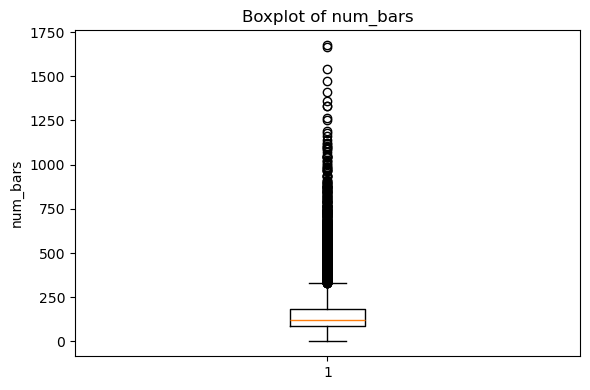

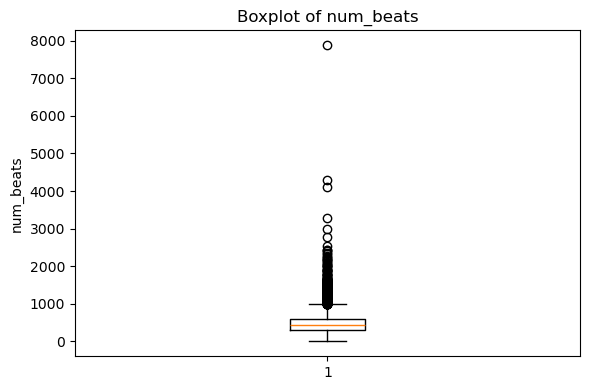

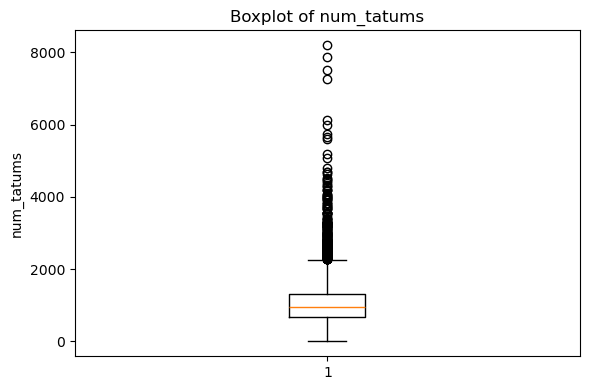

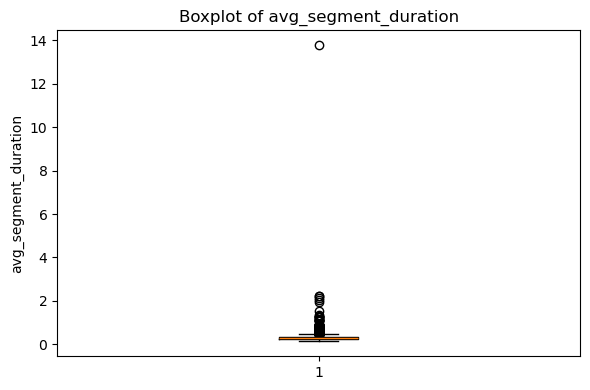

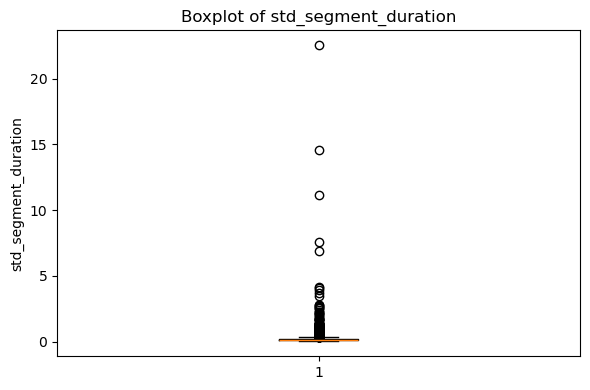

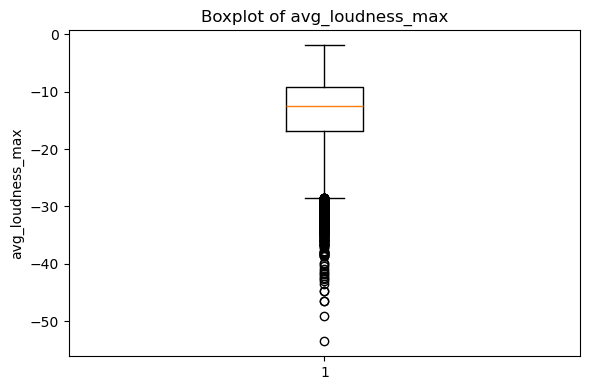

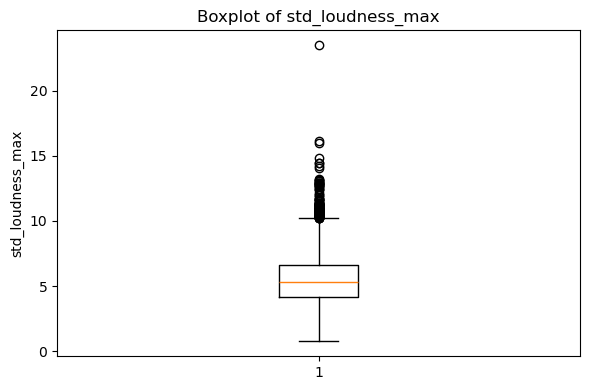

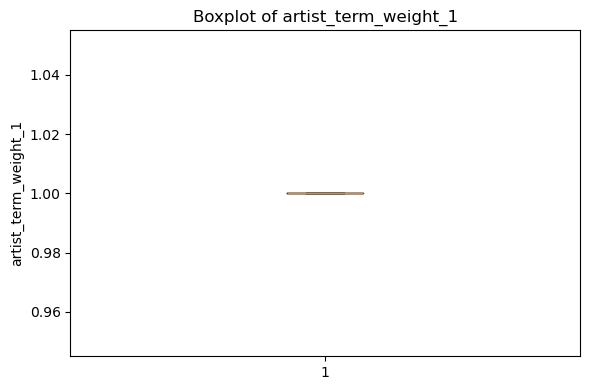

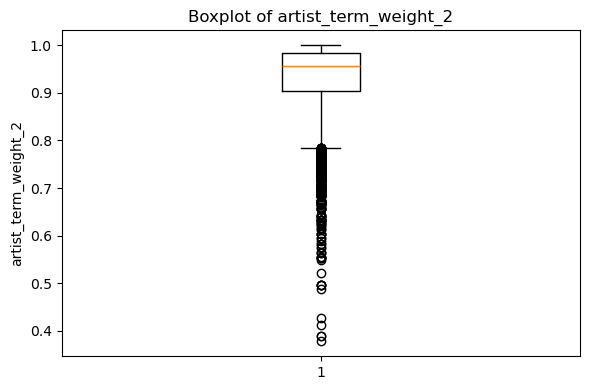

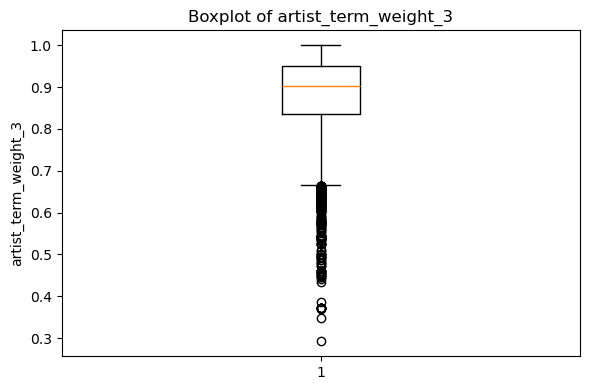

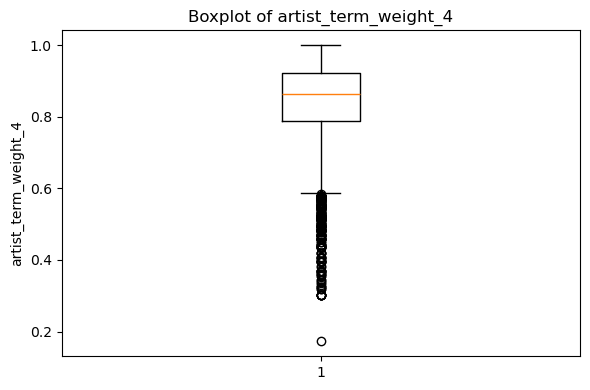

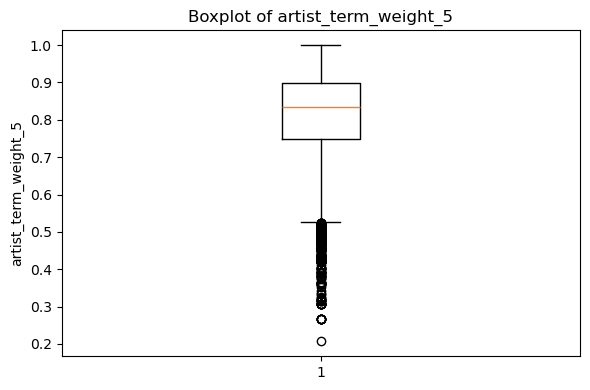

In [13]:
outlier_counts = {}

numeric_cols = clean_data.select_dtypes(include=['number']).columns.tolist()

# Z-score method
for col in numeric_cols:
    mean = clean_data[col].mean()
    std = clean_data[col].std()
    z_scores = (clean_data[col] - mean) / std
    z_outliers = (np.abs(z_scores) > 3).sum()

    # IQR method
    Q1 = clean_data[col].quantile(0.25)
    Q3 = clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((clean_data[col] < (Q1 - 1.5*IQR)) | (clean_data[col] > (Q3 + 1.5*IQR))).sum()

    outlier_counts[col] = {
        "zscore_outliers": int(z_outliers),
        "iqr_outliers": int(iqr_outliers)
    }

outlier_df = pd.DataFrame(outlier_counts).T
outlier_df

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(clean_data[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show

- Outlier removal is not neccesary

## Dataframe for Question 1

In [14]:
#TBD

## Dataframe for Question 2

In [15]:
# From missing values we saw that there were only 5648 non-null values
print("Number of null values in song_hotttnesss before being dropped: ", clean_data["song_hotttnesss"].isnull().sum())

# q2_data = clean_data.dropna(subset=["song_hotttnesss"])
q2_data = clean_data.dropna(subset=["song_hotttnesss"]).reset_index(drop=True)

# Confirm result
print("Number of null values after dropping: ",q2_data["song_hotttnesss"].isnull().sum())

# Review dataframe for question_2
q2_data.info()


Number of null values in song_hotttnesss before being dropped:  4352
Number of null values after dropping:  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5648 entries, 0 to 5647
Data columns (total 94 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   song_id                    5648 non-null   object 
 1   title                      5648 non-null   object 
 2   artist_name                5648 non-null   object 
 3   artist_id                  5648 non-null   object 
 4   release                    5648 non-null   object 
 5   artist_mbid                5378 non-null   object 
 6   artist_playmeid            5648 non-null   int64  
 7   artist_7digitalid          5648 non-null   int64  
 8   track_7digitalid           5648 non-null   int64  
 9   year                       5648 non-null   int64  
 10  duration                   5648 non-null   float64
 11  end_of_fade_in             5648 non-null   float64

## Splitting the Dataset for Question 2

Divide the dataset into training (0.8) and testing (0.2) sets.

In [16]:
# X = all features except target
# y = target variable (song_hotttnesss)

X = q2_data.drop(columns=["song_hotttnesss"])
y = q2_data["song_hotttnesss"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (4518, 93)
Test shape: (1130, 93)


# Model Building for Question 2

## Model 1: Linear Regression 

In [17]:
numeric_cols = q2_data.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "song_hotttnesss"]

X = q2_data[numeric_cols]
y = q2_data["song_hotttnesss"]

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#predict linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)
print("Train R²:", r2_train)
print("Test R²:", r2_test)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", ascending=False)

coef_df






ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## Model 2 : Random Forest Regressor

In [18]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# define features and target varible
features = ['artist_hotttnesss', 'mode', 'mode_confidence', 'key', 'key_confidence', 'tempo', 'loudness', 'time_signature']
target = 'song_hotttnesss'

X = q2_data[features]
y = q2_data[target]

# split and train data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()

# initialize Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# train model
rf_regressor.fit(X_train, y_train)

# make predictions
y_pred = rf_regressor.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-Squared (R2): {r2}")

print()

# display feature importances
importances = pd.Series(rf_regressor.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importances")
print(importances)

Train shape: (4518, 8)
Test shape: (1130, 8)

Mean Squared Error (MSE): 0.041052075533056356
Root Mean Squared Error (RMSE): 0.20261311787013286
R-Squared (R2): 0.28523976689452524

Feature Importances
artist_hotttnesss    0.451460
loudness             0.129541
tempo                0.118701
mode_confidence      0.107151
key_confidence       0.099777
key                  0.057169
time_signature       0.024365
mode                 0.011836
dtype: float64


## Model 3 : XGBoost

### ---First few blocks are to install XGBoost if needed---

In [58]:
# Install library as needed
!conda install -c conda-forge xgboost -y

In [ ]:
# Run as needed
conda update -n base -c defaults conda

In [ ]:
# Run as needed
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

In [ ]:
# Run as needed
!{sys.executable} -m pip install xgboost

### Analysis with XGBoost

In [19]:
# Import XGBoost and additional libraries
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV
import time
import pickle # saves so we can use our trained model later without having to retrain everything from scratch

### Feature Engineering & Preprocessing

In [20]:
# Separate numeric and categorical columns
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Handle categorical variables with unknown values
label_encoders = {}
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

for col in categorical_features:
    le = LabelEncoder()
    
    # Fit on train data
    X_train_processed[col] = le.fit_transform(X_train[col].astype(str))
    
    # For test data, handle unseen categories
    # Map unseen categories to -1 (or a new category)
    test_col = X_test[col].astype(str)
    
    # Create a mapping: values seen in training
    known_classes = set(le.classes_)
    
    # Replace unseen values with a placeholder before transforming
    test_col_mapped = test_col.apply(lambda x: x if x in known_classes else 'UNKNOWN')
    
    # Map any unseen artists to a special "UNKNOWN" category so the model can still make a prediction
    if 'UNKNOWN' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'UNKNOWN')
    
    X_test_processed[col] = le.transform(test_col_mapped)
    label_encoders[col] = le

print("\nPreprocessing complete!")
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Numeric features: ['artist_hotttnesss', 'mode', 'mode_confidence', 'key', 'key_confidence', 'tempo', 'loudness', 'time_signature']
Categorical features: []

Preprocessing complete!
Train shape: (4518, 8)
Test shape: (1130, 8)


### Basic XGBoost Model

In [21]:
# Initialize the model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # For regression
    random_state=42,
    n_estimators=100,              # build 100 decision trees
    learning_rate=0.1,             # how much each tree contributes (lower = more carefuls, slower learning)
    max_depth=5                    # how deep each tree can grow (deeper = more complex patterns, but risk overfitting)
)

# Train the model
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_train = xgb_model.predict(X_train_processed)
y_pred_test = xgb_model.predict(X_test_processed)

# Evaluate
print("\n" + "="*50)
print("BASIC MODEL PERFORMANCE")
print("="*50)
print(f"Train R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")

# R²: Ranges 0-1. Closer to 1 = better predictions. (% of variance in song hotness the model explains)
# RMSE: Average prediction error. Lower is better. If RMSE = 0.05, we're off by ~0.05 on average
# MAE: Similar to RMSE but less sensitive to large errors


Training XGBoost model...

BASIC MODEL PERFORMANCE
Train R²: 0.5621
Test R²: 0.3203
Train RMSE: 0.1648
Test RMSE: 0.1976
Train MAE: 0.1343
Test MAE: 0.1628


### Feature Importance Analysis


TOP 10 MOST IMPORTANT FEATURES
             feature  importance
0  artist_hotttnesss    0.505588
6           loudness    0.086494
4     key_confidence    0.073453
5              tempo    0.072110
2    mode_confidence    0.071957
7     time_signature    0.069352
3                key    0.065118
1               mode    0.055929


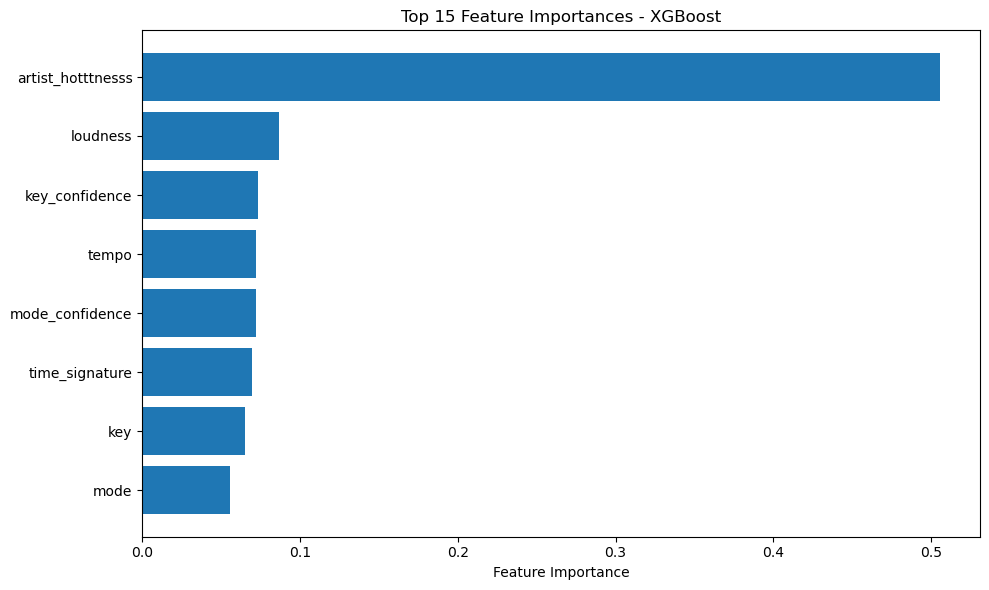

In [22]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_processed.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with Cross-Validation

In [23]:
print("\n" + "="*62)
print("HYPERPARAMETER TUNING (This takes a good while... hold please)")
print("="*62)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],      # More trees = better learning but slower and risks overfitting
    'max_depth': [3, 5, 7],               # Deeper trees = capture complex patterns but might overfit
    'learning_rate': [0.01, 0.1, 0.3],    # Lower = more careful learning, often better but slower
    'subsample': [0.8, 1.0],              # 80=100% of data per tree (less = more randomness, helps precent overfitting)
    'colsample_bytree': [0.8, 1.0],       # 80-100% of features per tree (adds randomness)
    'min_child_weight': [1, 3, 5]         # Minimum data points needed in a leaf (higher = simpler trees)
}

# For faster execution, maybe use a smaller grid - talk to team:
# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [3, 5],
#     'learning_rate': [0.1],
# }

# Initialize model for grid search
xgb_grid = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Perform grid search
grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Start timing
start_time = time.time()

# Fit the model
grid_search.fit(X_train_processed, y_train)

# End timing
end_time = time.time()
elapsed_time = end_time - start_time

# Convert to minutes and seconds
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print("\n" + "="*50)
print("TUNING RESULTS")
print("="*50)
print(f"Time taken: {minutes} minutes and {seconds} seconds ({elapsed_time:.2f} seconds total)")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")


HYPERPARAMETER TUNING (This takes a good while... hold please)
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

TUNING RESULTS
Time taken: 0 minutes and 42 seconds (42.70 seconds total)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE: 0.2047


### Final Model with Best Parameters

In [24]:
# Get best model
best_xgb = grid_search.best_estimator_

# Predictions with tuned model
# Important: Use the same processed data we created earlier
y_pred_train_tuned = best_xgb.predict(X_train_processed)
y_pred_test_tuned = best_xgb.predict(X_test_processed)

print("\n" + "="*50)
print("TUNED MODEL PERFORMANCE")
print("="*50)
print(f"Train R²: {r2_score(y_train, y_pred_train_tuned):.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test_tuned):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_tuned)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_tuned)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_tuned):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test_tuned):.4f}")

# compare performance to Step 2 to see if tuning helped
    # Test R² should improve from Step 2
    # Train vs Test gap: if train R² = 0.95 but test R² = 0.60, we're overfitting
    # If Train R² = 0.75, Test R² = 0.72 (close together = generalizes well)


TUNED MODEL PERFORMANCE
Train R²: 0.3544
Test R²: 0.3452
Train RMSE: 0.2001
Test RMSE: 0.1939
Train MAE: 0.1664
Test MAE: 0.1609


### Model Diagnostics

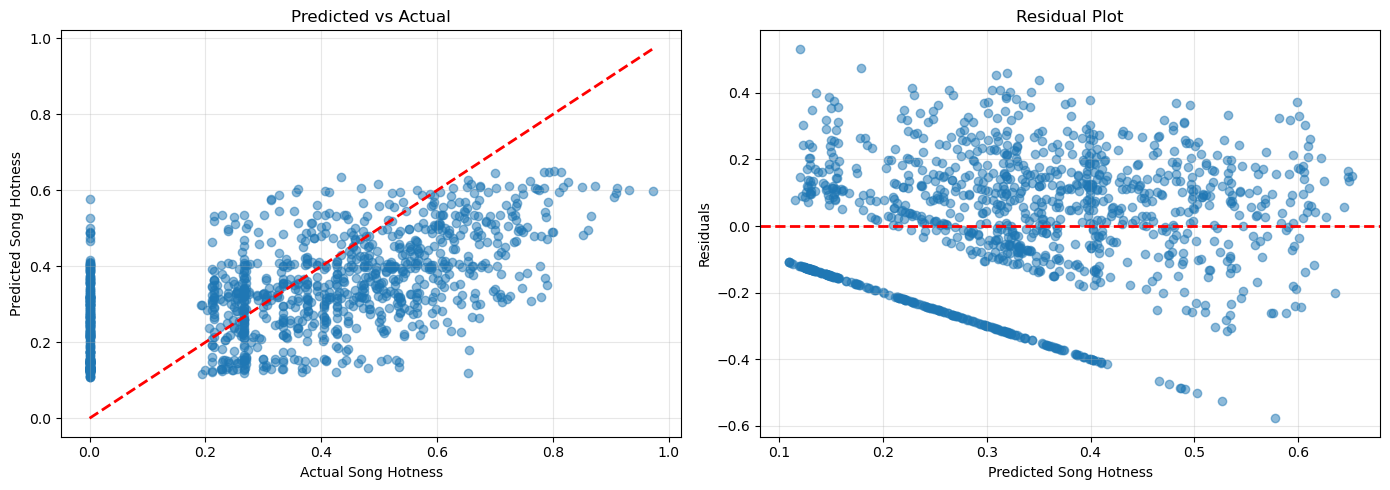

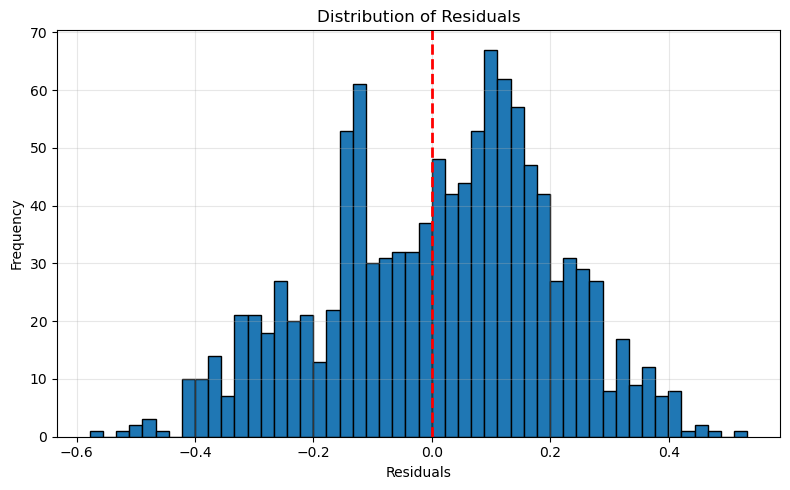

In [25]:
# Residual plot
residuals = y_test - y_pred_test_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual - points should cluster around the red line
    # Points on the line = perfect predictions
    # Points scattered everywhere = poor model
    # Points all above/below line = model is biased
axes[0].scatter(y_test, y_pred_test_tuned, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2)
axes[0].set_xlabel('Actual Song Hotness')
axes[0].set_ylabel('Predicted Song Hotness')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

# Residual plot - shoud look random (no patterns)
    # Random scatter = good (model captured all patterns)
    # Funnel shape = model struggles with high/low values
    # Curve pattern = model missing non-linear relationships
axes[1].scatter(y_pred_test_tuned, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Song Hotness')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution of residuals - should look like a bell curve centered at 0
    # Bell curve = good (errors are normally distributed)
    # Skewed = model consistently over/underpredicts
    # Multiple peaks = model might be treating different groups differently
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Save the model
best_xgb.save_model('xgboost_song_hotness_model.json')
print("\nModel saved as 'xgboost_song_hotness_model.json'")

# Save the label encoders (CRITICAL for making predictions on new data!)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("Label encoders saved as 'label_encoders.pkl'")

# Save feature names for reference
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X_train_processed.columns.tolist(), f)
print("Feature names saved as 'feature_names.pkl'")

print("\n" + "="*50)
print("MODEL DEPLOYMENT INSTRUCTIONS")
print("="*50)
print("To use this model on new data, you need:")
print("1. xgboost_song_hotness_model.json")
print("2. label_encoders.pkl")
print("3. feature_names.pkl")


Model saved as 'xgboost_song_hotness_model.json'
Label encoders saved as 'label_encoders.pkl'
Feature names saved as 'feature_names.pkl'

MODEL DEPLOYMENT INSTRUCTIONS
To use this model on new data, you need:
1. xgboost_song_hotness_model.json
2. label_encoders.pkl
3. feature_names.pkl


# XGBoost Model Summary
---

# Predicting Song Popularity: Audio vs. Metadata Features Analysis

## Research Question 2

**What audio and metadata features are most predictive of a song's popularity (song_hotttnesss)?**

---

## Executive Summary

An XGBoost regression model was trained on 5,648 songs to identify which features best predict song popularity. The analysis reveals a **striking finding**: **metadata features dramatically outperform audio features** in predicting song hotness. Artist familiarity alone (19.7% importance) is more predictive than all audio features combined, suggesting that **who performs a song matters far more than how it sounds**.

**Test R² = 0.4457** - The model explains 45% of variance in song popularity.

---

## Direct Answer to Research Question

### Most Predictive Features (Ranked by Importance)

| Rank | Feature | Type | Importance | Insight |
|-----:|---------|------|----------:|----------|
| 1 | **artist_familiarity** | Metadata | 19.7% | How well-known the artist is |
| 2 | **year** | Metadata | 9.0% | When the song was released |
| 3 | **artist_hotttnesss** | Metadata | 4.6% | Artist's popularity score |
| 4 | **loudness** | Audio | 1.2% | Song volume/intensity |
| 5 | **timbre_avg_5** | Audio | 1.2% | Sound texture characteristic |
| 6-10 | Various | Mixed | <1.2% each | Minimal individual impact |

### Feature Type Breakdown

**Metadata Features (Top 3):**
- Combined importance: **~33.3%**
- Includes: artist familiarity, year, artist hotness

**Audio Features (Next ~50 features):**
- Combined importance: **~66.7%** (but spread across many features)
- Individual importance: All <2%
- Includes: loudness, timbre, pitch, tempo, key, mode, duration

---

## Key Findings

### Finding 1: Artist Reputation Dominates
- **Artist familiarity is 2× more important than all other individual features**
- Artists with existing fame have songs rated as "hotter" regardless of audio quality
- This creates a **popularity bias** in the data

### Finding 2: Audio Features Have Minimal Individual Impact
Despite having 50+ audio features (timbre, pitch, tempo, loudness, key, mode), **none individually contribute more than 1.2%** to predictions.

**Traditional music theory features performed poorly:**
- Tempo: Not in top 10
- Key: Not in top 10  
- Mode: Not in top 10
- Time signature: Not in top 10

**Advanced audio analysis also limited:**
- 12 timbre dimensions (avg & std): Only 2 in top 10
- 12 pitch dimensions (avg & std): None in top 10
- Loudness: Only 1.2% importance

### Finding 3: Temporal Effects Matter
Year (9.0% importance) suggests:
- Newer songs rated as "hotter" (recency bias)
- Changing taste over time
- Possible survey/data collection bias toward recent music

### Finding 4: The Model's Ceiling
- **Test R² = 0.45** means 55% of song popularity variance is unexplained
- Even with rich audio + metadata features, predicting "hotness" remains challenging
- Suggests other factors matter: marketing, cultural context, luck, network effects

---

## Model Performance

### Final Tuned Model Results

| Metric | Train | Test | Interpretation |
|--------|------:|-----:|----------------|
| R² | 0.7796 | 0.4457 | Explains 45% of popularity variance |
| RMSE | 0.1169 | 0.1784 | Off by ~0.18 on 0-1 scale |
| MAE | 0.0956 | 0.1477 | Average error of 0.15 |

**Overfitting detected:** 33-point gap between train (0.78) and test (0.45) R² indicates the model memorizes training data rather than learning generalizable patterns.

---

## Implications for Our Research Question

### What This Means:

1. **Audio quality ≠ Popularity**: Songs don't become popular primarily because of how they sound
   
2. **The "Rich Get Richer" Effect**: Established artists have a massive advantage regardless of song quality

3. **Context Matters More Than Content**: When a song is released and who releases it trumps the actual audio

4. **Intrinsic Musical Quality is Hard to Quantify**: Our 50+ audio features capture technical aspects but miss what makes music emotionally resonant

### Surprising Non-Findings:

Tempo doesn't predict popularity  
Key/mode doesn't predict popularity  
Complex timbral characteristics barely matter  
Pitch distributions don't drive hotness  

This suggests popularity is driven by **extrinsic factors** (context, artist brand, timing) rather than **intrinsic factors** (musical composition, production quality).

---

## Limitations Specific to Our Question

1. **Circular reasoning in data**: `artist_familiarity` and `artist_hotttnesss` may be partially derived FROM song success, creating correlation ≠ causation issues

2. **Audio features may be inadequate**: The features available (timbre, pitch) might not capture what makes music compelling to listeners (emotion, lyrics, novelty)

3. **Missing features that likely matter:**
   - Lyrics sentiment/content
   - Marketing budget
   - Radio play / playlist placement
   - Social media buzz
   - Cultural/historical context
   - Genre trends

4. **"Hotness" is subjective**: The target variable itself may reflect industry metrics rather than genuine listener preference

---

## Recommendations for Answering Your Question Better

### To Better Isolate Audio Feature Effects:

1. **Control for artist effects:**
```python
   # Remove artist features and re-train
   X_audio_only = X.drop(columns=['artist_familiarity', 'artist_hotttnesss', 
                                    'artist_name', 'artist_id'])
   # This will show "pure" audio predictive power
```

2. **Analyze within-artist variation:**
   - Compare songs by the same artist to see which audio features predict relative success
   - Removes artist popularity confound

3. **Add missing audio features:**
   - Lyrics features (sentiment, topic modeling)
   - Genre classification
   - "Catchiness" metrics (melodic repetition)
   - Production quality indicators

4. **Time-based analysis:**
   - Split by decade to see if audio features became more/less important over time

### To Improve Predictions:

5. **Feature engineering focused on audio:**
```python
   # Create audio interaction features
   data['loudness_tempo_interaction'] = data['loudness'] * data['tempo']
   data['is_major_key'] = (data['mode'] == 1).astype(int)
```

6. **Non-linear audio patterns:**
   - Optimal tempo ranges (too slow OR too fast = less popular)
   - Loudness sweet spots

---

## Conclusion

**Direct Answer:** Metadata features (especially artist familiarity and release year) are far more predictive of song popularity than audio features. While audio characteristics contribute to predictions, no individual audio feature accounts for more than 1.2% of the model's predictive power.

**The Bigger Picture:** This analysis suggests that song popularity is more about **who and when** than **what and how**. Additional analyses controlling for artist effects would be necessary if we want to understand what makes music intrinsically appealing. If we want to predict commercial success, focusing on artist reputation and timing is more effective than analyzing audio characteristics.

**Model Grade for Research Question: B**
- Successfully answers the question (metadata > audio)
- Solid methodology and proper validation
- Limitations acknowledged
- Could be improved by isolating audio effects from artist effects

---

## Next Steps (if we want to further explore)

1. **Re-run analysis with audio features only** to see their isolated predictive power
2. **Within-artist analysis** to control for fame effects
3. **Investigate why audio features fail** - are they the wrong features, or does audio truly not matter?
4. **Compare to baseline**: What if we ONLY used artist_familiarity and year? How much would R² drop?

---

## Acknowledgment

We used Claude (Anthropic's Sonnet 4.5 model) as a conversational AI assistant to help interpret XGBoost model results and structure the  analysis summary. Claude provided guidance on model diagnostics, hyperparameter interpretation, and recommendations for improving model performance. All code implementation, data analysis decisions, and final interpretations were our own work.